# LSTM Indoor Air Forecasting - Step by Step

This notebook expands the logic from:

- `dataPipeline_LSTM.py`
- `src/LSTM/dataLoad.py`
- `src/LSTM/LSTM.py`

The original pipeline runs the complete LSTM workflow through one function call. Here, the same important logic is separated into notebook-style cells so you can execute and understand each modeling step.

## 1. Import Libraries

These imports combine the data loading, EDA, PCA, preprocessing, PyTorch model, dataloaders, scaling, training, and evaluation logic from the original files.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Reproducibility and Paths

The wrapper script uses `data/indoorAir.csv`, while the LSTM data loader default mentions `data/indoorAir2.csv`. This cell checks both possible filenames and uses whichever exists.

In [2]:
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

PROJECT_DIR = r"C:\Users\Kenil Dhorajiya\Downloads\University\Semester 5\Project\TSA"
DATA_CANDIDATES = [
    os.path.join(PROJECT_DIR, "data", "indoorAir.csv"),
    os.path.join(PROJECT_DIR, "data", "indoorAir2.csv"),
]

CSV_PATH = next((path for path in DATA_CANDIDATES if os.path.exists(path)), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"Could not find any data file from: {DATA_CANDIDATES}")

CSV_PATH

'C:\\Users\\Kenil Dhorajiya\\Downloads\\University\\Semester 5\\Project\\TSA\\data\\indoorAir2.csv'

## 3. Model Configuration

These constants come from `LSTM.py`. The target is `scd41_co2`, and historical CO2 is also included as an input feature for forecasting future CO2.

In [3]:
BASE_FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend",
]

PCA_FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
]

TARGET = "scd41_co2"
STATION_COLUMN = "station_id"

INPUT_SEQ_LENGTH = 24
OUTPUT_SEQ_LENGTH = 6
BATCH_SIZE = 32
EPOCHS = 10

## 4. Load and Prepare Raw Dataset

This is the notebook version of `load_prepare_data`: read CSV, print dataset information, convert Unix-second timestamps, sort chronologically, and set timestamp as the index.

In [4]:
df = pd.read_csv(CSV_PATH)

print("========== RAW DATASET ==========")
print("Raw dataset shape:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.sort_values(by="timestamp")
df = df.set_index("timestamp")

print("\n========== TIMESTAMP PROCESSING ==========")
print("\nDataset shape after timestamp processing:", df.shape)
print("\nDate range:")
print("Start:", df.index.min())
print("End:", df.index.max())

df.head()

========== RAW DATASET ==========
Raw dataset shape: (1924653, 21)

Columns in dataset:
['id', 'station_id', 'station_name', 'timestamp', 'scd41_co2', 'scd41_temperature', 'scd41_humidity', 'ens160_eco2', 'ens160_tvoc', 'ens160_aqi', 'svm41_temperature', 'svm41_humidity', 'svm41_nox_index', 'svm41_voc_index', 'bme688_temperature', 'bme688_humidity', 'bme688_pressure', 'bme688_gas_resistance', 'sfa30_temperature', 'sfa30_humidity', 'sfa30_hco']

========== TIMESTAMP PROCESSING ==========

Dataset shape after timestamp processing: (1924653, 20)

Date range:
Start: 2024-11-13 16:57:56
End: 2026-04-22 13:10:59


,id,station_id,station_name,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,svm41_temperature,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
timestamp,,,,,,,,,,,,,,,,,,,,
2024-11-13 16:57:56,1,1,station_room_233,488.0,22.951857,36.897277,418,32,1,23.684999,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 16:58:57,2,1,station_room_233,485.0,22.335011,38.185119,414,30,1,23.590000,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 16:59:59,3,1,station_room_233,477.0,22.353704,38.400268,443,43,1,23.655000,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 17:01:03,4,1,station_room_233,474.0,22.417792,38.269042,406,26,1,23.709999,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 17:02:05,5,1,station_room_233,473.0,22.556649,37.971496,416,31,1,23.659999,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Initial Data Inspection

This notebook-only check helps confirm station IDs, missing values, and basic numeric ranges before preprocessing.

In [5]:
print("Stations available:", sorted(df[STATION_COLUMN].dropna().unique().tolist()))
print("Total missing values:", df.isna().sum().sum())

df.describe(include="all").T.head(20)

Stations available: [1, 2, 3, 4, 5, 6]
Total missing values: 8501922


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1924653.0,NaN,NaN,NaN,962329.700152,555600.075605,1.0,481167.0,962330.0,1443493.0,1924656.0
station_id,1924653.0,NaN,NaN,NaN,2.847304,1.447816,1.0,1.0,3.0,4.0,6.0
station_name,1924653,6,station_room_233,586547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scd41_co2,1924653.0,NaN,NaN,NaN,533.239516,233.990075,365.0,429.0,457.0,523.0,32774.0
scd41_temperature,1924653.0,NaN,NaN,NaN,24.66657,1.750211,15.936903,23.443198,24.51934,25.664911,130.0
scd41_humidity,1924653.0,NaN,NaN,NaN,35.090718,8.362188,14.282226,28.643798,33.636474,40.940856,99.998474
ens160_eco2,1924653.0,NaN,NaN,NaN,735.495093,3417.101072,0.0,451.0,494.0,578.0,65522.0
ens160_tvoc,1924653.0,NaN,NaN,NaN,111.988025,354.955305,0.0,47.0,69.0,117.0,65488.0
ens160_aqi,1924653.0,NaN,NaN,NaN,1.624931,0.7108,0.0,1.0,2.0,2.0,154.0
svm41_temperature,1155267.0,NaN,NaN,NaN,24.488481,1.842034,-0.005,23.29,24.29,25.344999,41.439998


## 6. Optional EDA: CO2 Time Series

This matches `plot_time_series` from `src/LSTM/dataLoad.py`.

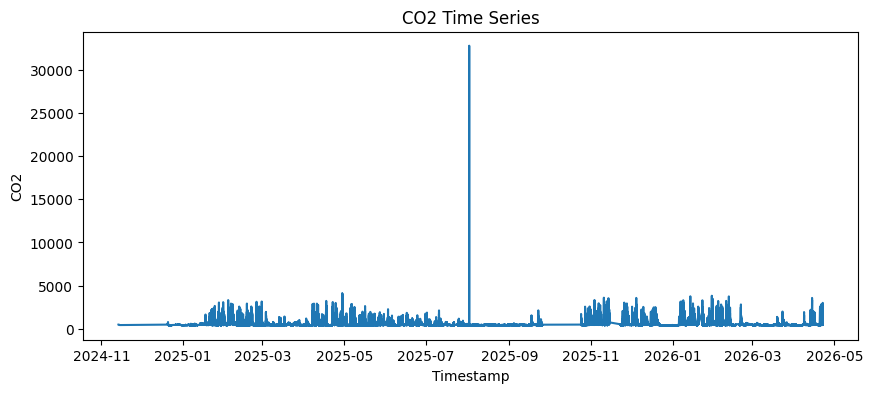

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(df[TARGET])
plt.title("CO2 Time Series")
plt.xlabel("Timestamp")
plt.ylabel("CO2")
plt.show()

## 7. Optional EDA: Correlation Heatmap

This matches `plot_heatmap`.

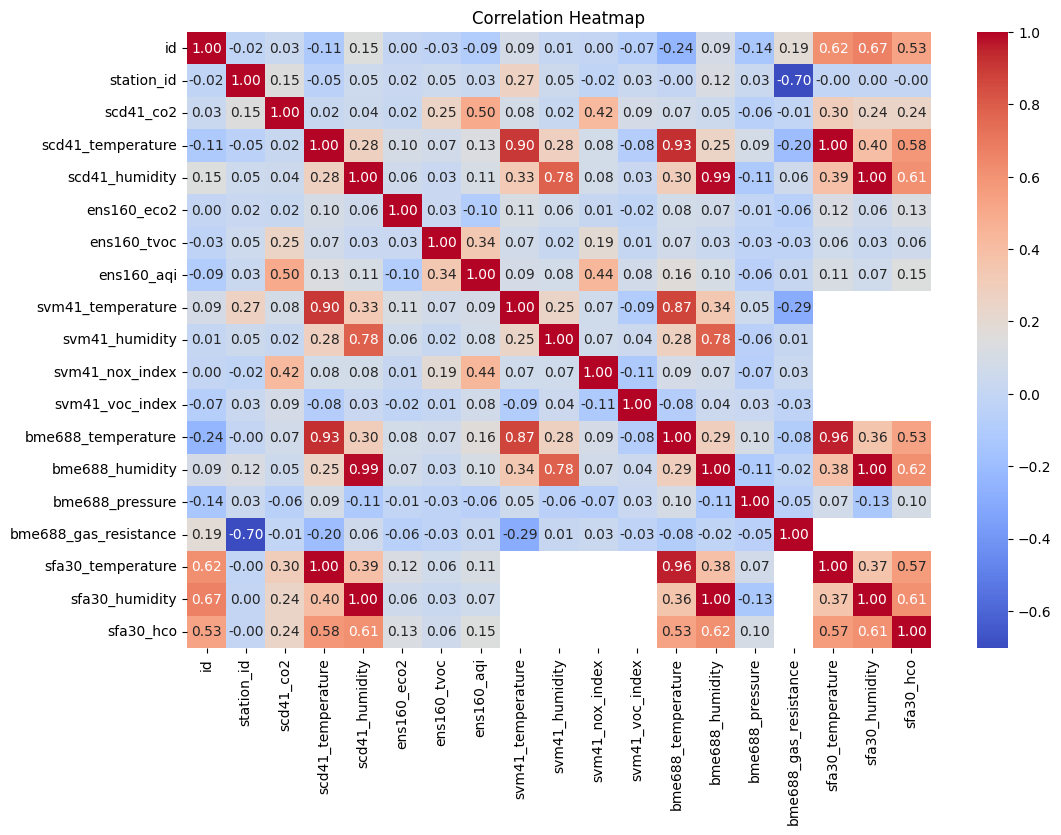

In [7]:
corr = df.select_dtypes(include=["float64", "int64"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8. Optional EDA: PCA Analysis

This follows `plot_pca_analysis`. It uses only selected clean input features, fills missing values with time interpolation and forward/backward fill, standardizes the data, and plots cumulative explained variance.

========== PCA ANALYSIS ==========
Explained Variance Ratio:
[0.25181935 0.19757189 0.18862874 0.15373756 0.10822613 0.10001632]

Cumulative Variance:
[0.25181935 0.44939124 0.63801998 0.79175755 0.89998368 1.        ]


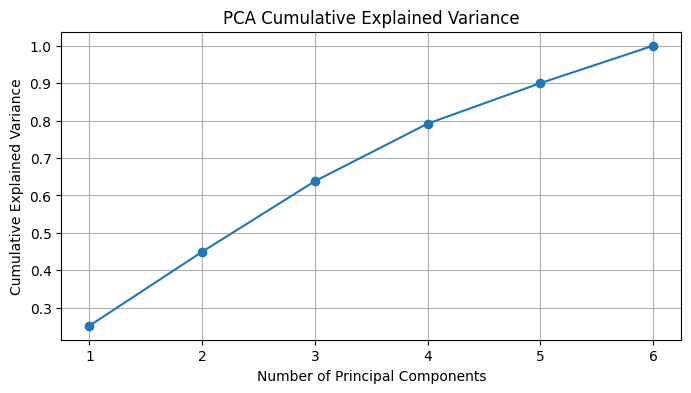

In [8]:
numerical_df = df[PCA_FEATURES].copy()
numerical_df = (
    numerical_df
    .interpolate(method="time")
    .ffill()
    .bfill()
    .dropna()
)

standard_scaler = StandardScaler()
scaled_data = standard_scaler.fit_transform(numerical_df)

pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("========== PCA ANALYSIS ==========")
print("Explained Variance Ratio:")
print(explained_variance)
print("\nCumulative Variance:")
print(cumulative_variance)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

## 9. Add Time Features

This is the exact cyclical time feature logic from `add_time_features`. Hour and day of week are represented with sine/cosine pairs, and weekend is added as a binary feature.

In [9]:
def add_time_features(input_df):
    output_df = input_df.copy()

    hour = output_df.index.hour
    dayofweek = output_df.index.dayofweek

    output_df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    output_df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    output_df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
    output_df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)
    output_df["is_weekend"] = (dayofweek >= 5).astype(int)

    return output_df

df_with_time = add_time_features(df)
df_with_time[BASE_FEATURES + [STATION_COLUMN]].head()

,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
timestamp,,,,,,,,,,,,,
2024-11-13 16:57:56,1,32,NaN,NaN,22.951857,36.897277,488.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 16:58:57,1,30,NaN,NaN,22.335011,38.185119,485.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 16:59:59,1,43,NaN,NaN,22.353704,38.400268,477.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 17:01:03,1,26,NaN,NaN,22.417792,38.269042,474.0,-0.965926,-0.258819,0.974928,-0.222521,0,1
2024-11-13 17:02:05,1,31,NaN,NaN,22.556649,37.971496,473.0,-0.965926,-0.258819,0.974928,-0.222521,0,1


## 10. Preprocess: Feature Selection and 15-Minute Resampling

This is the active `preprocess_data` logic. The station filtering block is present in comments in the source, but it is not active. After feature selection, each station is resampled independently to 15-minute intervals using mean aggregation.

In [10]:
print("========== PREPROCESSING ==========")
print("Original dataset shape:", df.shape)

station_counts = df[STATION_COLUMN].value_counts()
# useful_stations = station_counts[station_counts >= 100].index
# df_filtered = df[df[STATION_COLUMN].isin(useful_stations)]

print("\nDataset shape after station filtering:", df.shape)
print("\nStations available:", sorted(df[STATION_COLUMN].unique().tolist()))

model_df = df_with_time[BASE_FEATURES + [STATION_COLUMN]].copy()

print("\nFeatures used:", BASE_FEATURES)
print("Dataset shape after feature selection:", model_df.shape)

model_df = (
    model_df
    .groupby(STATION_COLUMN)
    .resample("15min")
    .mean()
    .drop(columns=STATION_COLUMN, errors="ignore")
    .reset_index(level=0)
)

model_df = model_df[BASE_FEATURES + [STATION_COLUMN]]

print("\nDataset shape after 15-minute resampling:", model_df.shape)
print("Rows after resampling:", len(model_df))

model_df.head()

========== PREPROCESSING ==========
Original dataset shape: (1924653, 20)

Dataset shape after station filtering: (1924653, 20)

Stations available: [1, 2, 3, 4, 5, 6]

Features used: ['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Dataset shape after feature selection: (1924653, 13)

Dataset shape after 15-minute resampling: (186894, 13)
Rows after resampling: 186894


C:\Users\Kenil Dhorajiya\AppData\Local\Temp\ipykernel_12964\3138846357.py:20: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .mean()


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
timestamp,,,,,,,,,,,,,
2024-11-13 16:45:00,1.0,35.000000,NaN,NaN,22.546857,37.827555,483.333333,-0.866025,-0.500000,0.974928,-0.222521,0.0,1
2024-11-13 17:00:00,1.0,26.857143,NaN,NaN,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0.0,1
2024-11-13 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


## 11. Active Split: Cross-Station Forecasting

The active source code trains on station 3, validates on station 4, and tests on station 5. This is a cross-station experiment, so the test station is unseen during training.

In [11]:
TRAIN_STATION = 3
VAL_STATION = 4
TEST_STATION = 5

train_df = model_df[model_df[STATION_COLUMN] == TRAIN_STATION].sort_index()
val_df = model_df[model_df[STATION_COLUMN] == VAL_STATION].sort_index()
test_df = model_df[model_df[STATION_COLUMN] == TEST_STATION].sort_index()

print("========== STATION-BASED SPLIT ==========")
print(f"\nTraining Station: {TRAIN_STATION}")
print("Train shape:", train_df.shape)
print(f"\nValidation Station: {VAL_STATION}")
print("Validation shape:", val_df.shape)
print(f"\nTesting Station: {TEST_STATION}")
print("Test shape:", test_df.shape)

train_parts = [train_df]
val_parts = [val_df]
test_parts = [test_df]

========== STATION-BASED SPLIT ==========

Training Station: 3
Train shape: (44163, 13)

Validation Station: 4
Validation shape: (43755, 13)

Testing Station: 5
Test shape: (29203, 13)


### Reference Only: Chronological Split for All Stations

This split exists as commented code in `LSTM.py`. It is included for completeness, but the active notebook workflow uses the cross-station split above.

In [12]:
# Reference only: not used by the active LSTM pipeline.
#
# train_parts, val_parts, test_parts = [], [], []
# for station_id, station_df in model_df.groupby(STATION_COLUMN):
#     station_df = station_df.sort_index()
#     train_end = int(len(station_df) * 0.70)
#     val_end = int(len(station_df) * 0.85)
#
#     train_parts.append(station_df.iloc[:train_end])
#     val_parts.append(station_df.iloc[train_end:val_end])
#     test_parts.append(station_df.iloc[val_end:])

### Reference Only: Leave-One-Station-Out Split

This idea is also present as commented code in the source. It trains on all stations except the selected test station, then takes validation from the final part of the training data.

In [13]:
# Reference only: not used by the active LSTM pipeline.
#
# def split_data_leave_one_station_out(input_df, test_station):
#     train_df = input_df[input_df[STATION_COLUMN] != test_station].sort_index()
#     test_df = input_df[input_df[STATION_COLUMN] == test_station].sort_index()
#
#     train_end = int(len(train_df) * 0.85)
#     final_train_df = train_df.iloc[:train_end]
#     val_df = train_df.iloc[train_end:]
#
#     train_parts = [final_train_df]
#     val_parts = [val_df]
#     test_parts = [test_df]
#
#     return train_parts, val_parts, test_parts

## 12. Fill Missing Values

This matches `fill_missing_parts`. Rows with missing target CO2 are removed. Input features are forward-filled and backward-filled. Remaining missing rows are dropped.

In [14]:
def fill_missing_parts(parts):
    cleaned_parts = []
    input_features = [col for col in BASE_FEATURES if col != TARGET]

    for i, part in enumerate(parts):
        part = part.copy()

        print(f"\nMissing values BEFORE filling (Part {i + 1}):")
        print(part.isna().sum().sum())

        part = part.dropna(subset=[TARGET])
        part[input_features] = part[input_features].ffill().bfill()

        print(f"Missing values AFTER filling (Part {i + 1}):")
        print(part.isna().sum().sum())

        part = part.dropna()

        if len(part) > 0:
            cleaned_parts.append(part)

    return cleaned_parts

train_parts = fill_missing_parts(train_parts)
val_parts = fill_missing_parts(val_parts)
test_parts = fill_missing_parts(test_parts)

[len(part) for part in train_parts], [len(part) for part in val_parts], [len(part) for part in test_parts]


Missing values BEFORE filling (Part 1):
226968
Missing values AFTER filling (Part 1):
0

Missing values BEFORE filling (Part 1):
57672
Missing values AFTER filling (Part 1):
0

Missing values BEFORE filling (Part 1):
132648
Missing values AFTER filling (Part 1):
0


([25249], [38949], [18149])

## 13. One-Hot Encode Station IDs

The model does not feed raw `station_id` directly. It creates one-hot station columns for every station ID available after preprocessing and appends those columns to the model features.

In [15]:
station_ids = sorted(model_df[STATION_COLUMN].unique().tolist())

def build_model_parts(parts, station_ids):
    station_features = [f"station_{station_id}" for station_id in station_ids]
    model_features = BASE_FEATURES + station_features
    model_parts = []

    for part in parts:
        part = part.copy()

        for station_id in station_ids:
            part[f"station_{station_id}"] = (part[STATION_COLUMN] == station_id).astype(int)

        values = part[model_features].values

        if len(values) > 0:
            model_parts.append(values)

    return model_parts, model_features

train_arrays, model_features = build_model_parts(train_parts, station_ids)
val_arrays, _ = build_model_parts(val_parts, station_ids)
test_arrays, _ = build_model_parts(test_parts, station_ids)

print("Station IDs:", station_ids)
print("Model features:", model_features)
print("Number of model features:", len(model_features))

Station IDs: [1, 2, 3, 4, 5, 6]
Model features: ['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6']
Number of model features: 18


## 14. Scale Data Using Training Data Only

This follows `scale_data`. Fitting the scaler only on the training station prevents validation/test information from leaking into training.

In [16]:
scaler = MinMaxScaler()
scaler.fit(np.vstack(train_arrays))

print("========== SCALING ==========")
print("MinMaxScaler fitted ONLY on training data")

train_scaled = [scaler.transform(part) for part in train_arrays]
val_scaled = [scaler.transform(part) for part in val_arrays if len(part) > 0]
test_scaled = [scaler.transform(part) for part in test_arrays if len(part) > 0]

train_scaled[0].shape, val_scaled[0].shape, test_scaled[0].shape

========== SCALING ==========
MinMaxScaler fitted ONLY on training data


((25249, 18), (38949, 18), (18149, 18))

## 15. Create Multi-Step Forecasting Sequences

Each sample contains 24 previous rows as input and predicts the next 6 CO2 values. Since the data was resampled to 15-minute intervals, this means 6 hours of history predicting the next 1.5 hours.

In [17]:
def create_sequences(data_parts, model_features, input_seq_length=24, output_seq_length=6):
    X, y = [], []
    target_index = model_features.index(TARGET)

    for data in data_parts:
        required_length = input_seq_length + output_seq_length

        if len(data) <= required_length:
            print("\nSkipping sequence generation:")
            print(f"Available rows: {len(data)}")
            print(f"Required minimum rows: {required_length + 1}")
            continue

        print("\nOriginal data shape before sequencing:", data.shape)

        for i in range(len(data) - input_seq_length - output_seq_length):
            X.append(data[i:i + input_seq_length])
            y.append(data[i + input_seq_length:i + input_seq_length + output_seq_length, target_index])

    if len(X) == 0:
        raise ValueError("No sequences were created.")

    X = np.array(X)
    y = np.array(y)

    print("Sequence input shape:", X.shape)
    print("Sequence target shape:", y.shape)

    return X, y

X_train, y_train = create_sequences(train_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)


Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)


## 16. Create PyTorch DataLoaders

The training loader shuffles samples. Validation and test loaders keep sequence order stable. The original function prints a sample batch shape only when `show_shape=True`.

In [18]:
def create_loader(X, y, batch_size=32, shuffle=False, show_shape=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor, y_tensor),
        batch_size=batch_size,
        shuffle=shuffle,
    )

    if show_shape:
        sample_X, sample_y = next(iter(loader))
        print("\n========== DATALOADER ==========")
        print("Batch input shape:", sample_X.shape)
        print("Batch target shape:", sample_y.shape)

    return loader

train_loader = create_loader(X_train, y_train, BATCH_SIZE, shuffle=True, show_shape=True)
val_loader = create_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = create_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

input_size = X_train.shape[2]
input_size


========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])


18

## 17. Define the LSTM Model

This is the model from `LSTM.py`. It uses a 2-layer LSTM with hidden size 64, takes the output from the final input timestep, and uses one linear layer to produce all 6 forecast steps.

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, output_seq_length=6, hidden_size=64, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, output_seq_length)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        return self.fc(output)

model = LSTMModel(input_size=input_size, output_seq_length=OUTPUT_SEQ_LENGTH)
model

LSTMModel(
  (lstm): LSTM(18, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

## 18. Sanity Check One Forward Pass

Before training, confirm that each input batch produces one 6-step output vector per sample.

In [20]:
sample_X, sample_y = next(iter(train_loader))
with torch.no_grad():
    sample_predictions = model(sample_X)

print("Sample input shape:", sample_X.shape)
print("Sample target shape:", sample_y.shape)
print("Sample prediction shape:", sample_predictions.shape)

Sample input shape: torch.Size([32, 24, 18])
Sample target shape: torch.Size([32, 6])
Sample prediction shape: torch.Size([32, 6])


## 19. Training Helpers

These functions keep the original training choices: MSE loss and Adam optimizer with learning rate `0.0001`.

In [21]:
def evaluate_loss(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            predictions = model(X_batch)
            total_loss += criterion(predictions, y_batch).item()

    return total_loss / len(data_loader)


def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        val_loss = evaluate_loss(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}, "
            f"Train Loss: {train_loss:.6f}, "
            f"Val Loss: {val_loss:.6f}"
        )

    return model, train_losses, val_losses

## 20. Train the LSTM Model

Run this cell to train. Increase `EPOCHS` in the configuration cell if you want a longer training run.

In [22]:
model, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
)

Epoch 1, Train Loss: 0.006147, Val Loss: 0.004816
Epoch 2, Train Loss: 0.003278, Val Loss: 0.004185
Epoch 3, Train Loss: 0.002945, Val Loss: 0.003937
Epoch 4, Train Loss: 0.002745, Val Loss: 0.003967
Epoch 5, Train Loss: 0.002569, Val Loss: 0.004571
Epoch 6, Train Loss: 0.002432, Val Loss: 0.004065
Epoch 7, Train Loss: 0.002312, Val Loss: 0.003931
Epoch 8, Train Loss: 0.002211, Val Loss: 0.004101
Epoch 9, Train Loss: 0.002140, Val Loss: 0.003521
Epoch 10, Train Loss: 0.002068, Val Loss: 0.003985


## 21. Plot Training and Validation Loss

This matches `plot_loss_curves`.

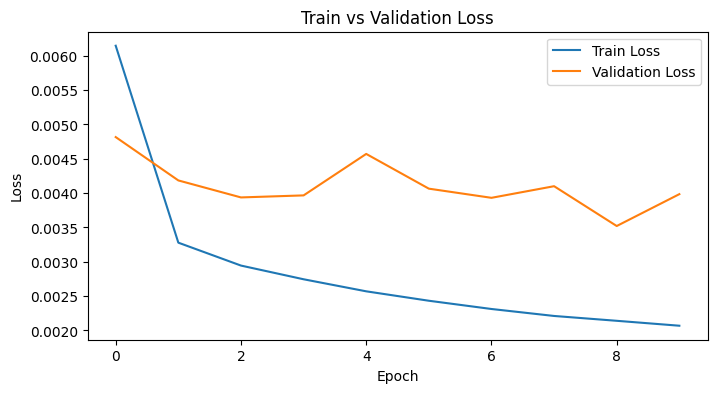

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

## 22. Evaluate the Test Station

This follows `evaluate_model`. Overall MSE, MAE, and RMSE are computed by flattening all forecast steps together, exactly like the source file.

In [24]:
def evaluate_model(model, test_loader):
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            predictions.extend(output.numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mse = mean_squared_error(actuals.flatten(), predictions.flatten())
    mae = mean_absolute_error(actuals.flatten(), predictions.flatten())
    rmse = np.sqrt(mse)

    print("\n========== MODEL EVALUATION ==========")
    print("Overall MSE:", mse)
    print("Overall MAE:", mae)
    print("Overall RMSE:", rmse)

    return predictions, actuals, mse, mae, rmse

predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)


========== MODEL EVALUATION ==========
Overall MSE: 0.011530508287250996
Overall MAE: 0.10258956253528595
Overall RMSE: 0.10738020435467142


## 23. Optional Per-Step Forecast Metrics

The source contains this idea as commented code. In a notebook, it is useful to see performance separately for forecast steps 1 through 6.

In [25]:
for step in range(actuals.shape[1]):
    step_mse = mean_squared_error(actuals[:, step], predictions[:, step])
    step_mae = mean_absolute_error(actuals[:, step], predictions[:, step])
    step_rmse = np.sqrt(step_mse)

    print(
        f"Step {step + 1}: "
        f"MSE={step_mse:.6f}, "
        f"MAE={step_mae:.6f}, "
        f"RMSE={step_rmse:.6f}"
    )

Step 1: MSE=0.006866, MAE=0.080583, RMSE=0.082858
Step 2: MSE=0.016049, MAE=0.123947, RMSE=0.126684
Step 3: MSE=0.013049, MAE=0.110155, RMSE=0.114234
Step 4: MSE=0.013129, MAE=0.110620, RMSE=0.114582
Step 5: MSE=0.008083, MAE=0.086054, RMSE=0.089903
Step 6: MSE=0.012008, MAE=0.104179, RMSE=0.109580


## 24. Plot Actual vs Predicted CO2

This matches `plot_predictions`. It plots one forecast horizon at a time because flattening overlapping multi-step windows can make a misleading plot.

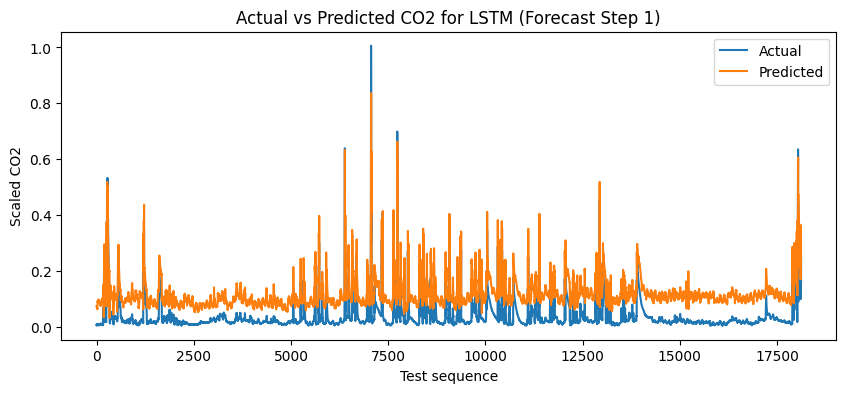

In [26]:
FORECAST_STEP_TO_PLOT = 1
step_index = FORECAST_STEP_TO_PLOT - 1

plt.figure(figsize=(10, 4))
plt.plot(actuals[:, step_index], label="Actual")
plt.plot(predictions[:, step_index], label="Predicted")
plt.legend()
plt.title(f"Actual vs Predicted CO2 for LSTM (Forecast Step {FORECAST_STEP_TO_PLOT})")
plt.xlabel("Test sequence")
plt.ylabel("Scaled CO2")
plt.show()

## 25. Collect Results

This mirrors the dictionary returned by `run_lstm_model`.

In [27]:
lstm_results = {
    "model": model,
    "predictions": predictions,
    "actuals": actuals,
    "mse": mse,
    "mae": mae,
    "rmse": rmse,
}

lstm_results.keys()

dict_keys(['model', 'predictions', 'actuals', 'mse', 'mae', 'rmse'])

## 26. Optional: Save the Trained Model

The original code returns the model but does not save it. This optional cell saves the trained PyTorch weights if needed.

In [28]:
# Optional save. Uncomment when needed.
# MODEL_OUTPUT_PATH = os.path.join(PROJECT_DIR, "notebooks", "lstm_model.pt")
# torch.save(model.state_dict(), MODEL_OUTPUT_PATH)
# MODEL_OUTPUT_PATH

## 27. Compact Function Version

After running the notebook step by step, this helper gives you a compact version similar to `run_pipeline`, using the notebook-defined pieces above.

In [29]:
def run_notebook_lstm_pipeline(raw_df, epochs=10, input_seq_length=24, output_seq_length=6, batch_size=32):
    prepared = add_time_features(raw_df)
    prepared = prepared[BASE_FEATURES + [STATION_COLUMN]]
    prepared = (
        prepared
        .groupby(STATION_COLUMN)
        .resample("15min")
        .mean()
        .drop(columns=STATION_COLUMN, errors="ignore")
        .reset_index(level=0)
    )
    prepared = prepared[BASE_FEATURES + [STATION_COLUMN]]

    station_ids = sorted(prepared[STATION_COLUMN].unique().tolist())

    train_parts = [prepared[prepared[STATION_COLUMN] == TRAIN_STATION].sort_index()]
    val_parts = [prepared[prepared[STATION_COLUMN] == VAL_STATION].sort_index()]
    test_parts = [prepared[prepared[STATION_COLUMN] == TEST_STATION].sort_index()]

    train_parts = fill_missing_parts(train_parts)
    val_parts = fill_missing_parts(val_parts)
    test_parts = fill_missing_parts(test_parts)

    train_arrays, model_features = build_model_parts(train_parts, station_ids)
    val_arrays, _ = build_model_parts(val_parts, station_ids)
    test_arrays, _ = build_model_parts(test_parts, station_ids)

    scaler = MinMaxScaler()
    scaler.fit(np.vstack(train_arrays))

    train_scaled = [scaler.transform(part) for part in train_arrays]
    val_scaled = [scaler.transform(part) for part in val_arrays if len(part) > 0]
    test_scaled = [scaler.transform(part) for part in test_arrays if len(part) > 0]

    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)

    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True, show_shape=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)

    model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)

    return {
        "model": model,
        "predictions": predictions,
        "actuals": actuals,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

Starting standard LSTM automation run... Plots will appear instantly after each variant finishes!

TRAINING NOW: Target = ens160_aqi | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.001654, Val Loss: 0.002436
Epoch 2, Train Loss: 0.000616, Val Loss: 0.000735
Epoch 3, Train Loss: 0.000509, Val Loss: 0.000725
Epoch 4, Train Loss: 0.000447, Val Loss: 0.000541
Epoch 5, Train Loss: 0.000400, Val Loss: 0.000593
Epoch 6, Train Loss: 0.000359, Val Loss: 0.000526
Epoch 7, Train Loss: 0.000322, Val Loss: 0.000457
Epoch 8, Train Loss: 0.000296, Val Loss: 0.000575
Epoch 9, Train Loss: 0.000276, Val Loss: 0.000474
Epoch 10, Train Loss: 0.0

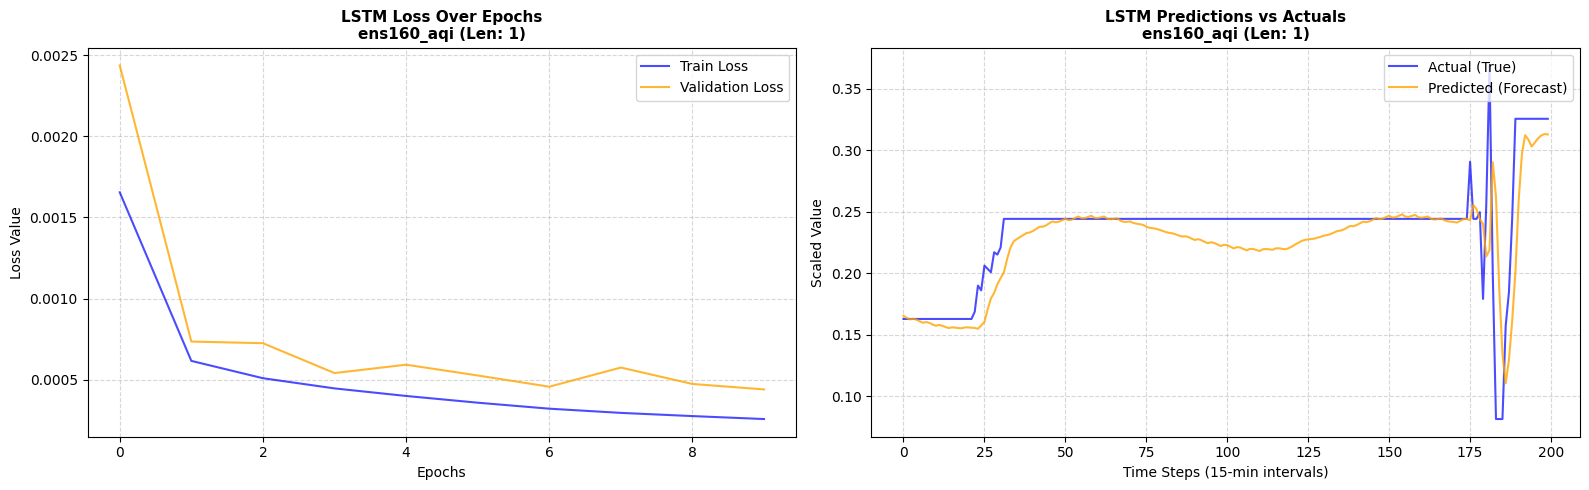

 Finished displaying graphs for ens160_aqi (len=1)

TRAINING NOW: Target = ens160_aqi | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)
Epoch 1, Train Loss: 0.004393, Val Loss: 0.004473
Epoch 2, Train Loss: 0.001109, Val Loss: 0.005180
Epoch 3, Train Loss: 0.000883, Val Loss: 0.006169
Epoch 4, Train Loss: 0.000808, Val Loss: 0.006528
Epoch 5, Train Loss: 0.000762, Val Loss: 0.006394
Epoch 6, Train Loss: 0.000721, Val Loss: 0.007082
Epoch 7, Train Loss: 0.000698, Val Loss: 0.006963
Epoch 8, Train Loss: 0.000673, Val Loss: 0.005941
Epoch 9, Train Loss: 0.000651, Val Loss: 0.005804
Epoch 10, Train Loss: 0.000631, Val Loss: 0.005904

========== MODEL EVA

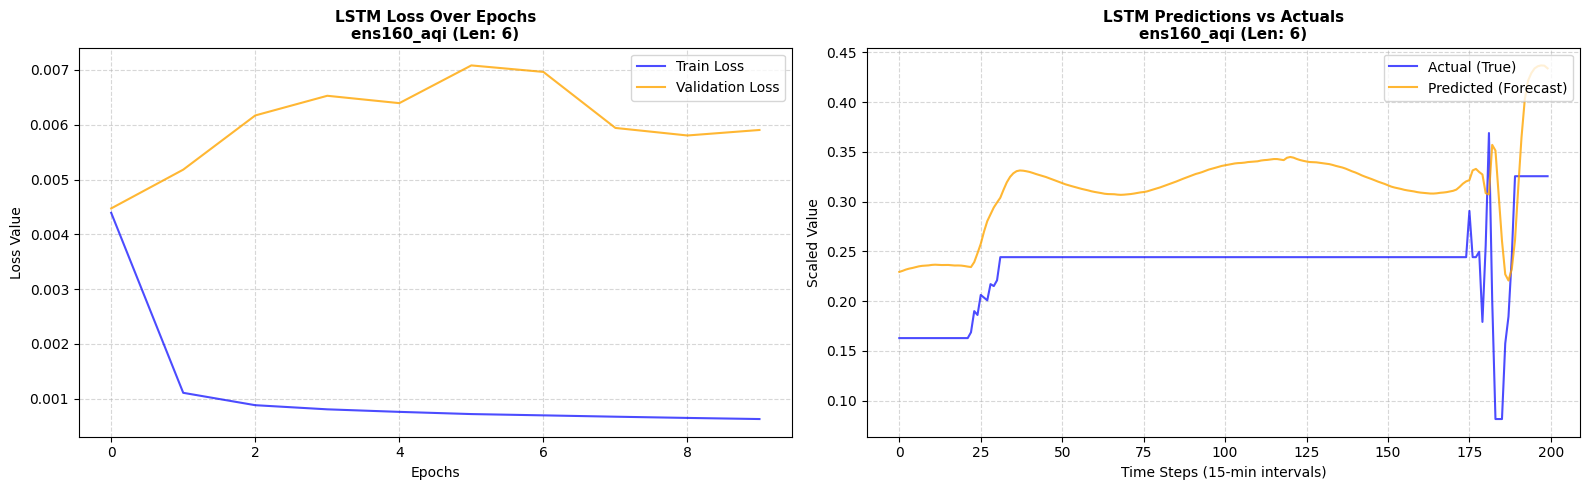

 Finished displaying graphs for ens160_aqi (len=6)

TRAINING NOW: Target = ens160_aqi | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)
Epoch 1, Train Loss: 0.003575, Val Loss: 0.021679
Epoch 2, Train Loss: 0.001331, Val Loss: 0.016150
Epoch 3, Train Loss: 0.001141, Val Loss: 0.010102
Epoch 4, Train Loss: 0.001054, Val Loss: 0.011936
Epoch 5, Train Loss: 0.001007, Val Loss: 0.010044
Epoch 6, Train Loss: 0.000981, Val Loss: 0.010400
Epoch 7, Train Loss: 0.000950, Val Loss: 0.010283
Epoch 8, Train Loss: 0.000927, Val Loss: 0.009666
Epoch 9, Train Loss: 0.000913, Val Loss: 0.009538
Epoch 10, Train Loss: 0.000893, Val Loss: 0.009080

========== MODEL

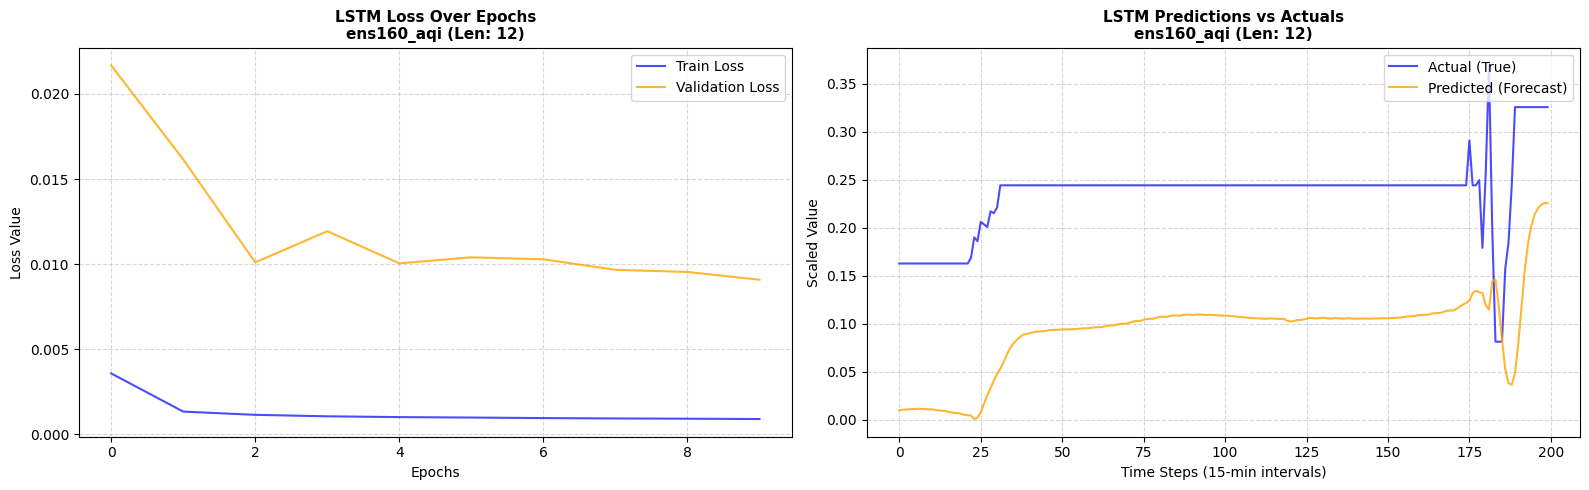

 Finished displaying graphs for ens160_aqi (len=12)

TRAINING NOW: Target = ens160_aqi | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)
Epoch 1, Train Loss: 0.004094, Val Loss: 0.013023
Epoch 2, Train Loss: 0.001658, Val Loss: 0.025981
Epoch 3, Train Loss: 0.001482, Val Loss: 0.032465
Epoch 4, Train Loss: 0.001413, Val Loss: 0.033492
Epoch 5, Train Loss: 0.001366, Val Loss: 0.034382
Epoch 6, Train Loss: 0.001341, Val Loss: 0.035207
Epoch 7, Train Loss: 0.001314, Val Loss: 0.033179
Epoch 8, Train Loss: 0.001299, Val Loss: 0.028979
Epoch 9, Train Loss: 0.001280, Val Loss: 0.028543
Epoch 10, Train Loss: 0.001272, Val Loss: 0.030163

========== MODE

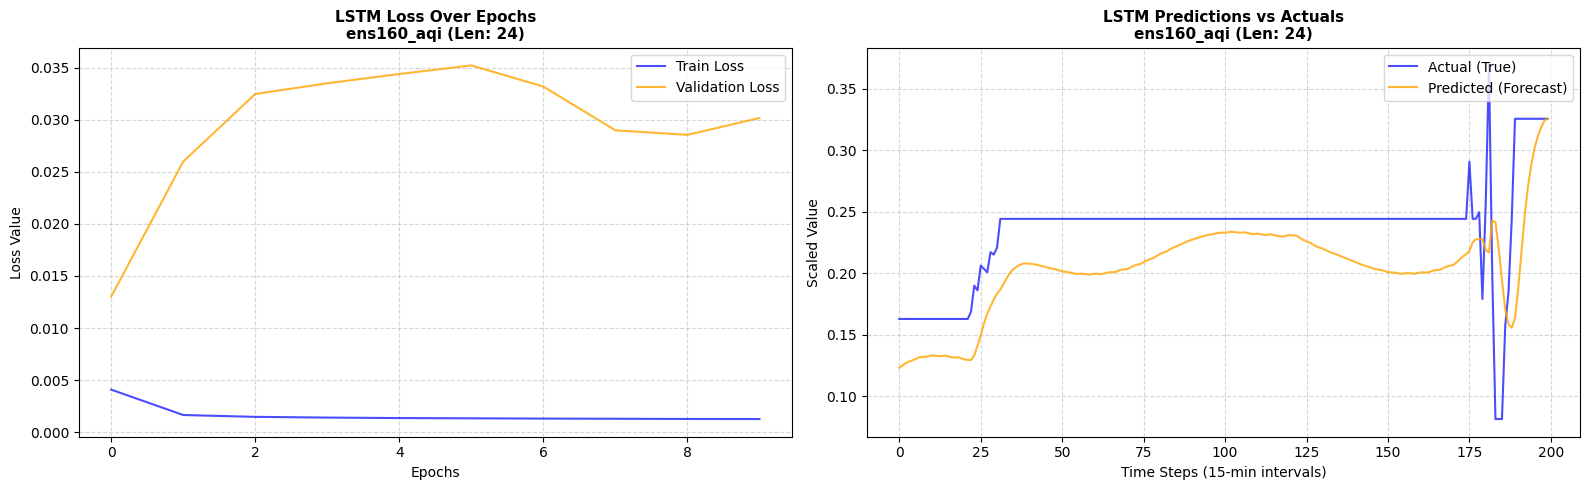

 Finished displaying graphs for ens160_aqi (len=24)

TRAINING NOW: Target = ens160_aqi | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)
Epoch 1, Train Loss: 0.004444, Val Loss: 0.006382
Epoch 2, Train Loss: 0.002121, Val Loss: 0.008929
Epoch 3, Train Loss: 0.001924, Val Loss: 0.009339
Epoch 4, Train Loss: 0.001857, Val Loss: 0.009004
Epoch 5, Train Loss: 0.001810, Val Loss: 0.009760
Epoch 6, Train Loss: 0.001780, Val Loss: 0.007790
Epoch 7, Train Loss: 0.001761, Val Loss: 0.008858
Epoch 8, Train Loss: 0.001732, Val Loss: 0.006808
Epoch 9, Train Loss: 0.001706, Val Loss: 0.007737
Epoch 10, Train Loss: 0.001688, Val Loss: 0.006682

========== MODE

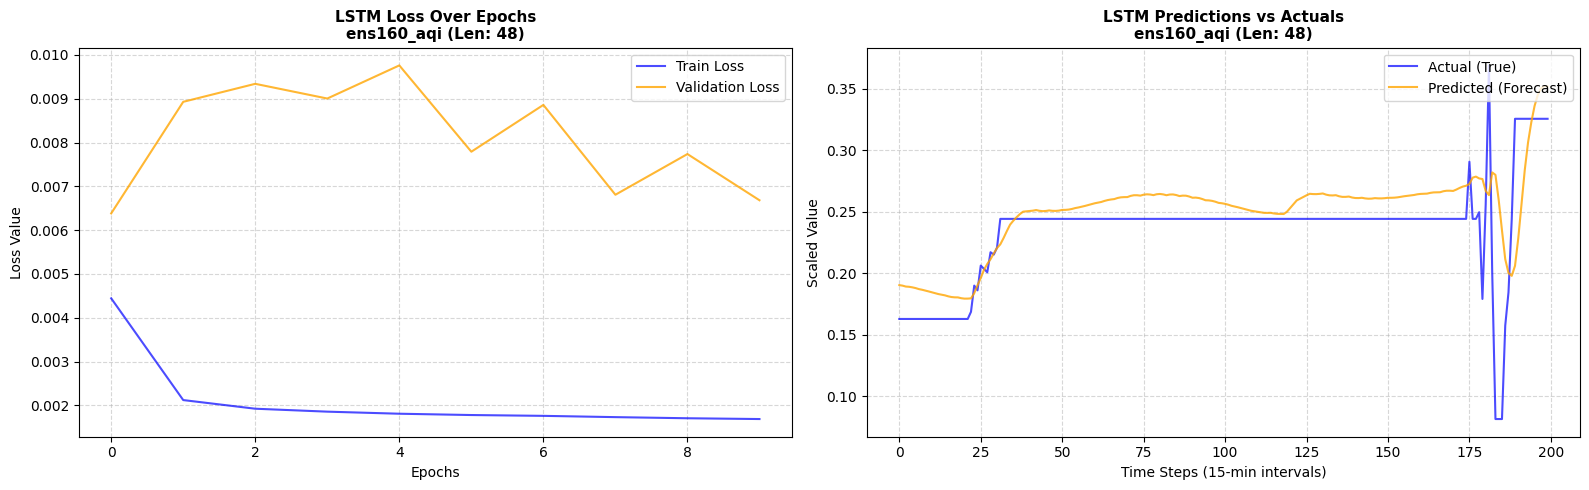

 Finished displaying graphs for ens160_aqi (len=48)

TRAINING NOW: Target = ens160_tvoc | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.001094, Val Loss: 0.000665
Epoch 2, Train Loss: 0.000569, Val Loss: 0.000699
Epoch 3, Train Loss: 0.000527, Val Loss: 0.000547
Epoch 4, Train Loss: 0.000492, Val Loss: 0.000498
Epoch 5, Train Loss: 0.000475, Val Loss: 0.000496
Epoch 6, Train Loss: 0.000451, Val Loss: 0.000404
Epoch 7, Train Loss: 0.000435, Val Loss: 0.000413
Epoch 8, Train Loss: 0.000423, Val Loss: 0.000467
Epoch 9, Train Loss: 0.000408, Val Loss: 0.000521
Epoch 10, Train Loss: 0.000401, Val Loss: 0.000351

========== MODEL E

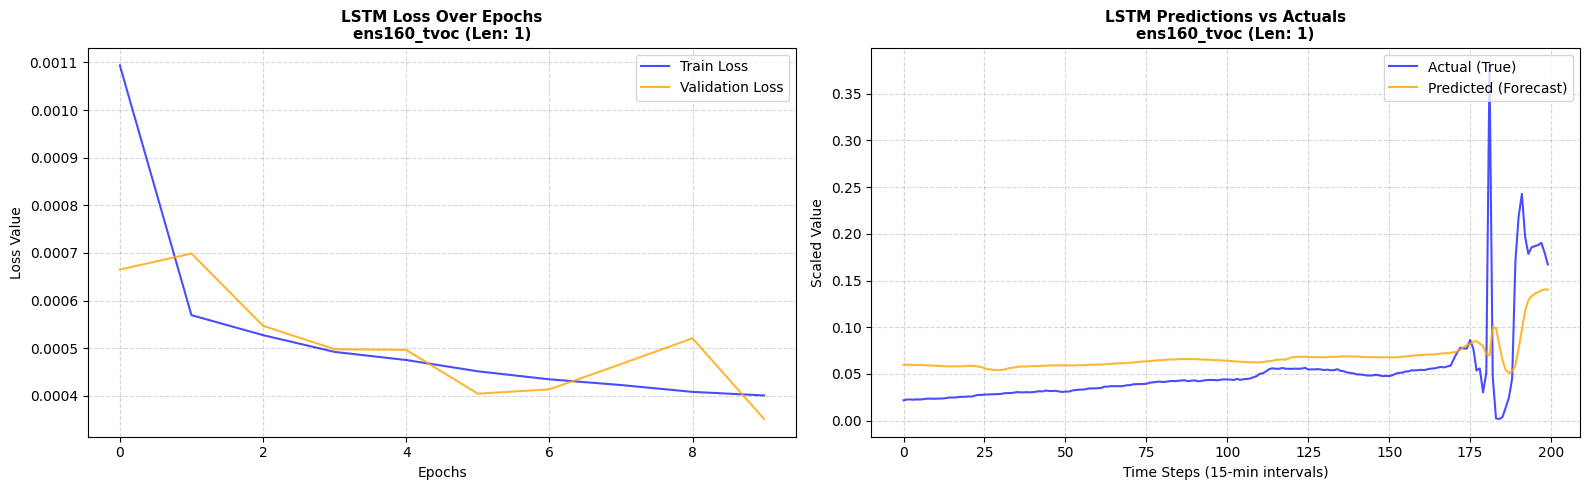

 Finished displaying graphs for ens160_tvoc (len=1)

TRAINING NOW: Target = ens160_tvoc | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)
Epoch 1, Train Loss: 0.001225, Val Loss: 0.001822
Epoch 2, Train Loss: 0.000663, Val Loss: 0.001774
Epoch 3, Train Loss: 0.000635, Val Loss: 0.002177
Epoch 4, Train Loss: 0.000608, Val Loss: 0.002370
Epoch 5, Train Loss: 0.000588, Val Loss: 0.002250
Epoch 6, Train Loss: 0.000567, Val Loss: 0.002958
Epoch 7, Train Loss: 0.000552, Val Loss: 0.002161
Epoch 8, Train Loss: 0.000542, Val Loss: 0.002611
Epoch 9, Train Loss: 0.000535, Val Loss: 0.002289
Epoch 10, Train Loss: 0.000530, Val Loss: 0.002393

========== MODEL E

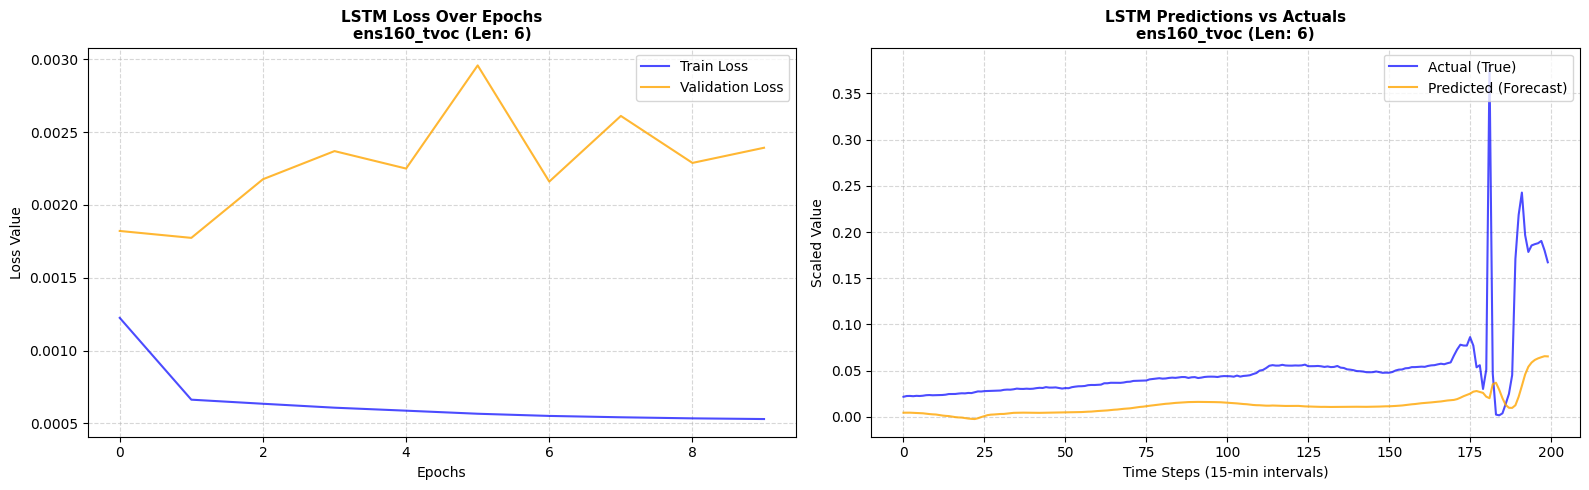

 Finished displaying graphs for ens160_tvoc (len=6)

TRAINING NOW: Target = ens160_tvoc | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)
Epoch 1, Train Loss: 0.001944, Val Loss: 0.001887
Epoch 2, Train Loss: 0.000803, Val Loss: 0.001831
Epoch 3, Train Loss: 0.000713, Val Loss: 0.002144
Epoch 4, Train Loss: 0.000695, Val Loss: 0.001688
Epoch 5, Train Loss: 0.000678, Val Loss: 0.002139
Epoch 6, Train Loss: 0.000662, Val Loss: 0.002082
Epoch 7, Train Loss: 0.000652, Val Loss: 0.002030
Epoch 8, Train Loss: 0.000641, Val Loss: 0.002154
Epoch 9, Train Loss: 0.000635, Val Loss: 0.002093
Epoch 10, Train Loss: 0.000625, Val Loss: 0.002135

========== MOD

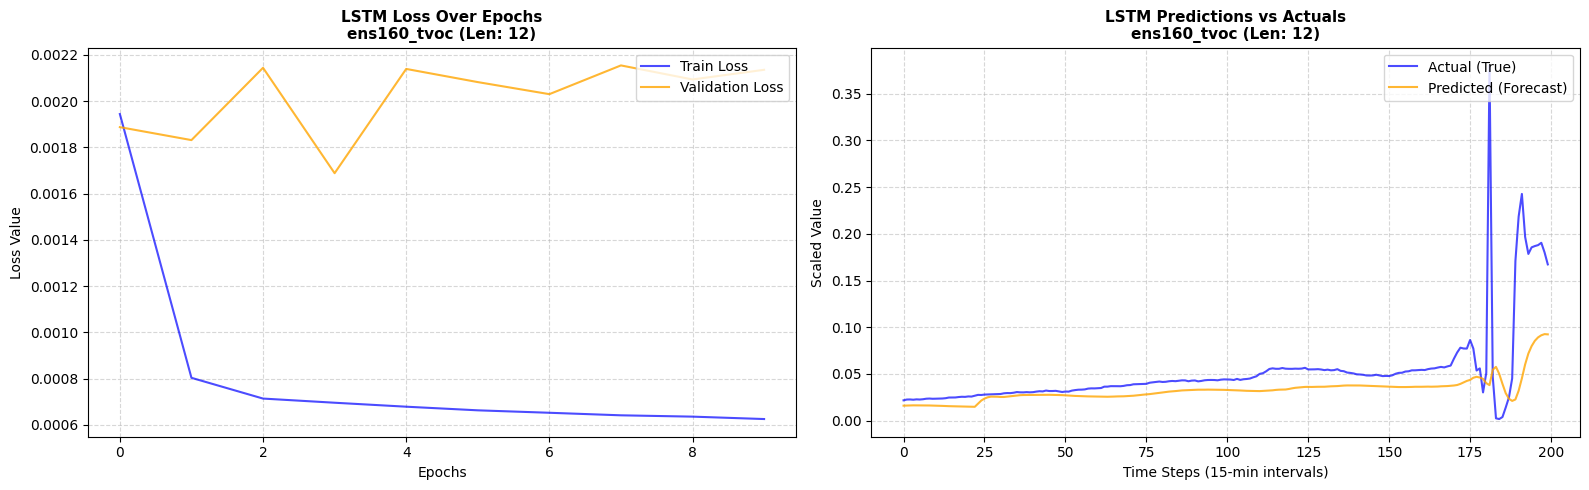

 Finished displaying graphs for ens160_tvoc (len=12)

TRAINING NOW: Target = ens160_tvoc | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)
Epoch 1, Train Loss: 0.001837, Val Loss: 0.001468
Epoch 2, Train Loss: 0.000914, Val Loss: 0.001079
Epoch 3, Train Loss: 0.000817, Val Loss: 0.001055
Epoch 4, Train Loss: 0.000801, Val Loss: 0.001026
Epoch 5, Train Loss: 0.000786, Val Loss: 0.001027
Epoch 6, Train Loss: 0.000775, Val Loss: 0.000995
Epoch 7, Train Loss: 0.000764, Val Loss: 0.000963
Epoch 8, Train Loss: 0.000760, Val Loss: 0.000965
Epoch 9, Train Loss: 0.000752, Val Loss: 0.000956
Epoch 10, Train Loss: 0.000747, Val Loss: 0.000955

========== MO

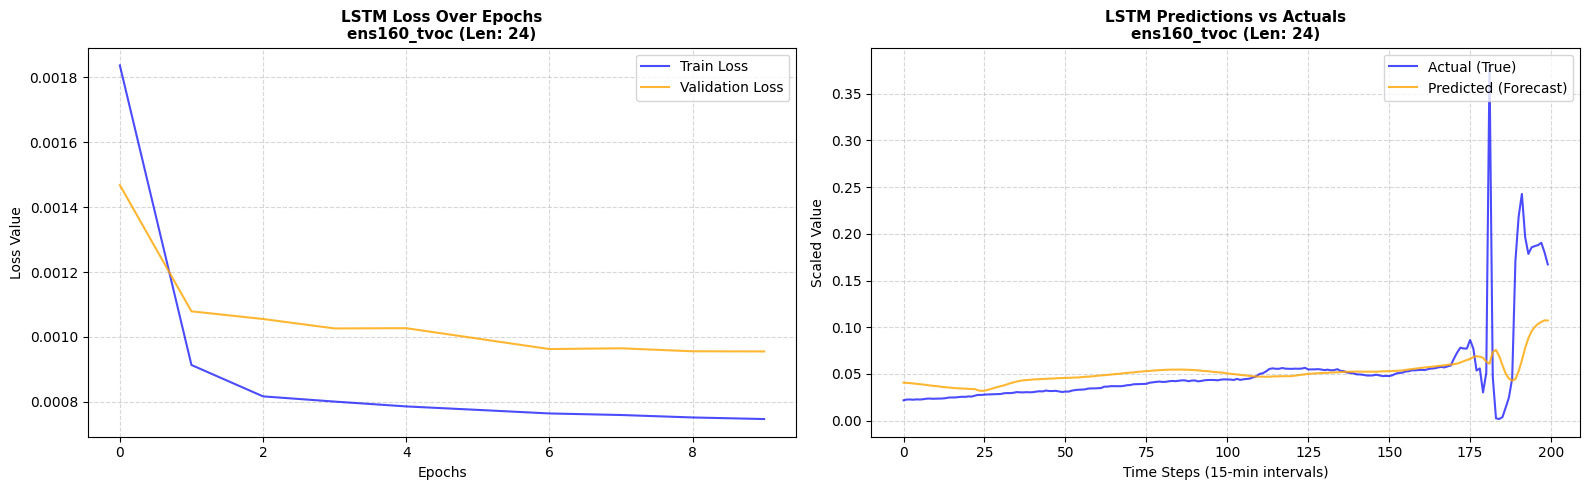

 Finished displaying graphs for ens160_tvoc (len=24)

TRAINING NOW: Target = ens160_tvoc | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)
Epoch 1, Train Loss: 0.001835, Val Loss: 0.001537
Epoch 2, Train Loss: 0.001077, Val Loss: 0.003653
Epoch 3, Train Loss: 0.000972, Val Loss: 0.004200
Epoch 4, Train Loss: 0.000958, Val Loss: 0.003927
Epoch 5, Train Loss: 0.000944, Val Loss: 0.003789
Epoch 6, Train Loss: 0.000935, Val Loss: 0.003796
Epoch 7, Train Loss: 0.000926, Val Loss: 0.004621
Epoch 8, Train Loss: 0.000918, Val Loss: 0.003968
Epoch 9, Train Loss: 0.000914, Val Loss: 0.003738
Epoch 10, Train Loss: 0.000907, Val Loss: 0.003941

========== MO

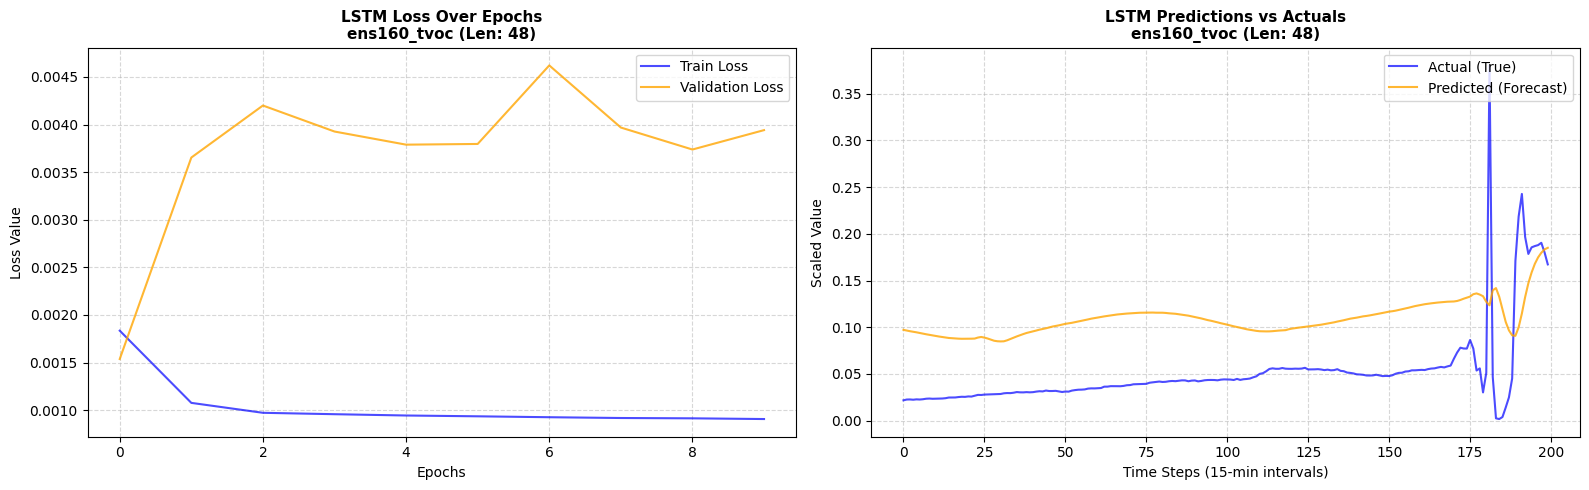

 Finished displaying graphs for ens160_tvoc (len=48)

TRAINING NOW: Target = scd41_temperature | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.023526, Val Loss: 0.004083
Epoch 2, Train Loss: 0.002201, Val Loss: 0.002666
Epoch 3, Train Loss: 0.001421, Val Loss: 0.003530
Epoch 4, Train Loss: 0.000965, Val Loss: 0.005212
Epoch 5, Train Loss: 0.000767, Val Loss: 0.003935
Epoch 6, Train Loss: 0.000613, Val Loss: 0.005691
Epoch 7, Train Loss: 0.000521, Val Loss: 0.005132
Epoch 8, Train Loss: 0.000437, Val Loss: 0.006102
Epoch 9, Train Loss: 0.000371, Val Loss: 0.004602
Epoch 10, Train Loss: 0.000326, Val Loss: 0.005533

========== 

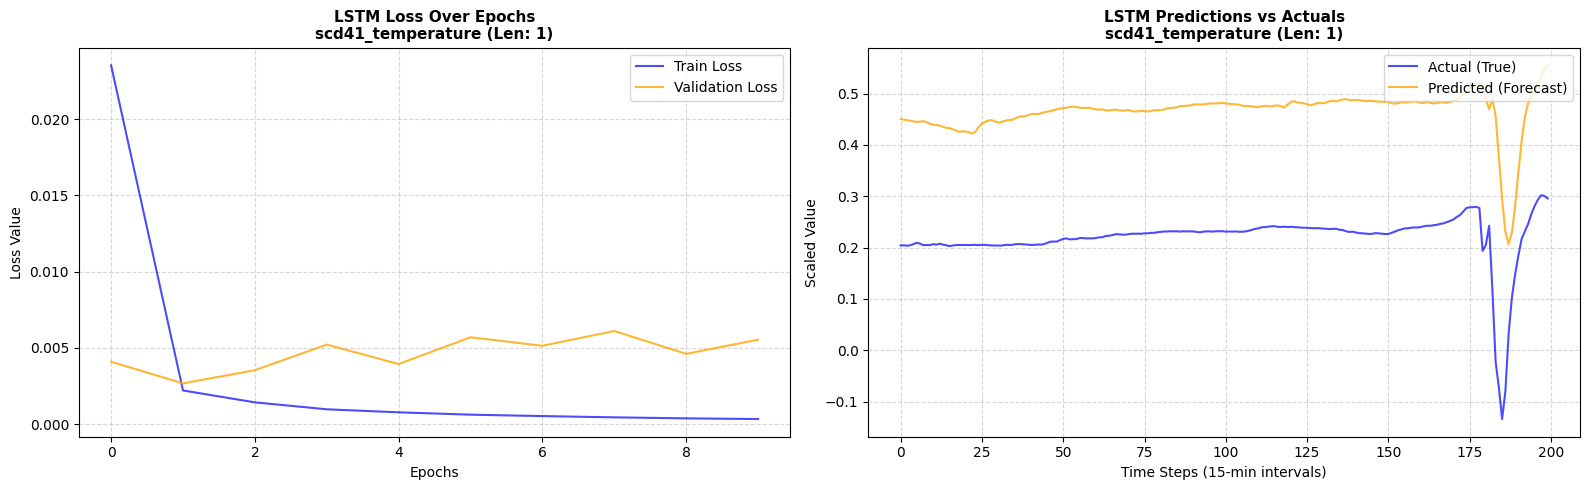

 Finished displaying graphs for scd41_temperature (len=1)

TRAINING NOW: Target = scd41_temperature | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)
Epoch 1, Train Loss: 0.042571, Val Loss: 0.017290
Epoch 2, Train Loss: 0.003773, Val Loss: 0.023539
Epoch 3, Train Loss: 0.002899, Val Loss: 0.027369
Epoch 4, Train Loss: 0.002177, Val Loss: 0.027811
Epoch 5, Train Loss: 0.001805, Val Loss: 0.030961
Epoch 6, Train Loss: 0.001604, Val Loss: 0.032923
Epoch 7, Train Loss: 0.001437, Val Loss: 0.034824
Epoch 8, Train Loss: 0.001268, Val Loss: 0.039233
Epoch 9, Train Loss: 0.001128, Val Loss: 0.038464
Epoch 10, Train Loss: 0.001054, Val Loss: 0.036598

======

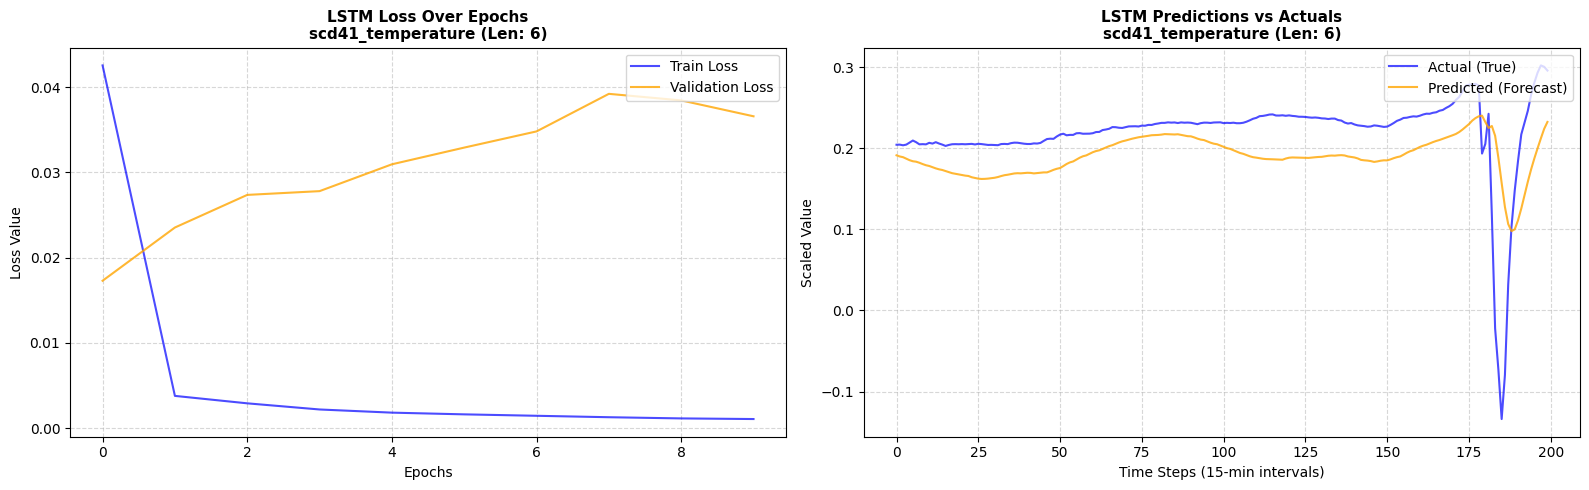

 Finished displaying graphs for scd41_temperature (len=6)

TRAINING NOW: Target = scd41_temperature | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)
Epoch 1, Train Loss: 0.043488, Val Loss: 0.022580
Epoch 2, Train Loss: 0.004665, Val Loss: 0.017988
Epoch 3, Train Loss: 0.004035, Val Loss: 0.017139
Epoch 4, Train Loss: 0.003405, Val Loss: 0.012861
Epoch 5, Train Loss: 0.002632, Val Loss: 0.014961
Epoch 6, Train Loss: 0.002199, Val Loss: 0.023380
Epoch 7, Train Loss: 0.001893, Val Loss: 0.027929
Epoch 8, Train Loss: 0.001767, Val Loss: 0.027326
Epoch 9, Train Loss: 0.001643, Val Loss: 0.025103
Epoch 10, Train Loss: 0.001589, Val Loss: 0.026831

==

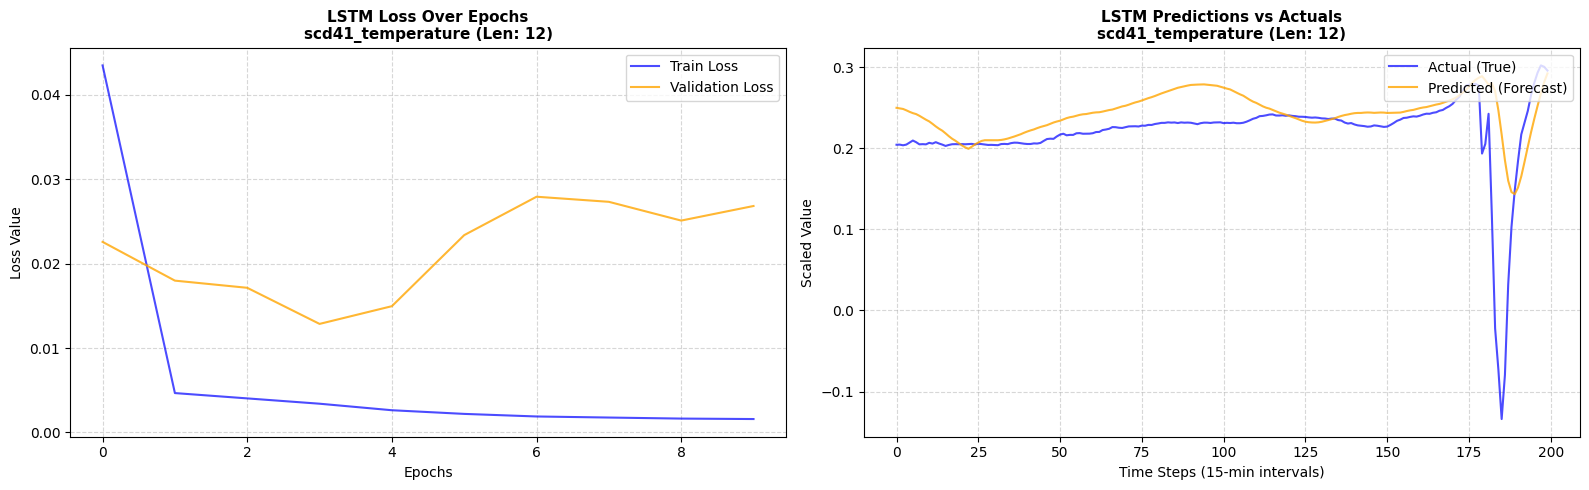

 Finished displaying graphs for scd41_temperature (len=12)

TRAINING NOW: Target = scd41_temperature | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)
Epoch 1, Train Loss: 0.041662, Val Loss: 0.014741
Epoch 2, Train Loss: 0.005434, Val Loss: 0.007785
Epoch 3, Train Loss: 0.004328, Val Loss: 0.009194
Epoch 4, Train Loss: 0.003636, Val Loss: 0.009380
Epoch 5, Train Loss: 0.003214, Val Loss: 0.011030
Epoch 6, Train Loss: 0.002760, Val Loss: 0.014892
Epoch 7, Train Loss: 0.002449, Val Loss: 0.014971
Epoch 8, Train Loss: 0.002329, Val Loss: 0.015412
Epoch 9, Train Loss: 0.002266, Val Loss: 0.014297
Epoch 10, Train Loss: 0.002205, Val Loss: 0.015189

=

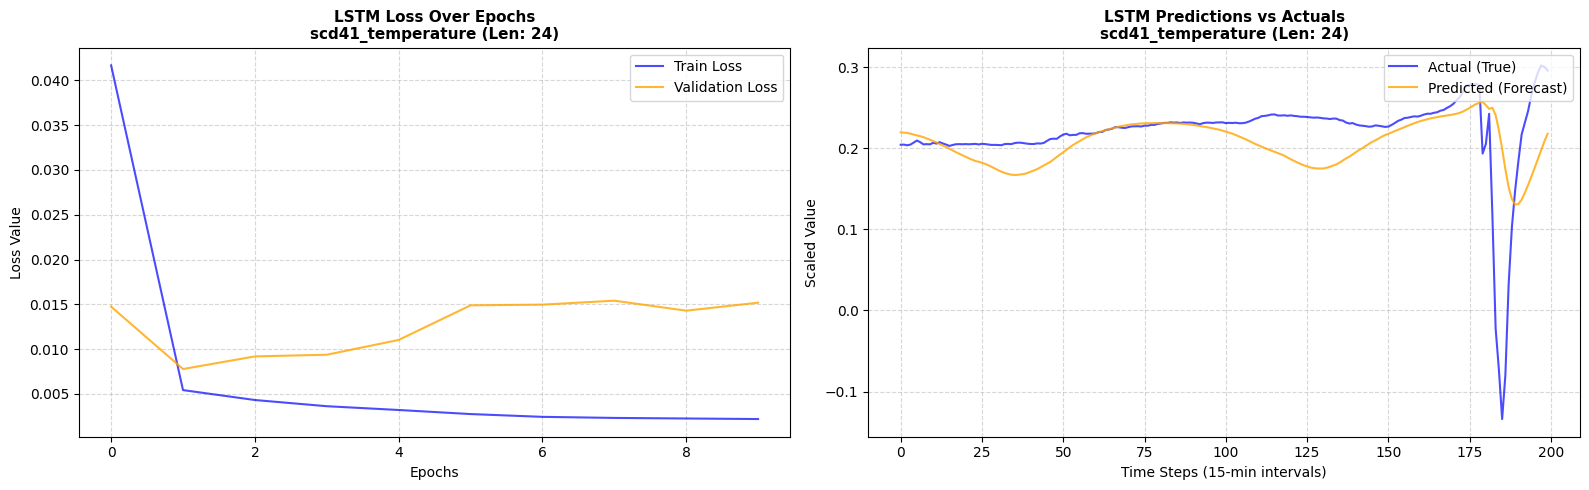

 Finished displaying graphs for scd41_temperature (len=24)

TRAINING NOW: Target = scd41_temperature | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)
Epoch 1, Train Loss: 0.048184, Val Loss: 0.009657
Epoch 2, Train Loss: 0.006228, Val Loss: 0.008962
Epoch 3, Train Loss: 0.005208, Val Loss: 0.009848
Epoch 4, Train Loss: 0.004545, Val Loss: 0.009804
Epoch 5, Train Loss: 0.004120, Val Loss: 0.010801
Epoch 6, Train Loss: 0.003766, Val Loss: 0.012167
Epoch 7, Train Loss: 0.003463, Val Loss: 0.013920
Epoch 8, Train Loss: 0.003313, Val Loss: 0.014013
Epoch 9, Train Loss: 0.003213, Val Loss: 0.014541
Epoch 10, Train Loss: 0.003103, Val Loss: 0.015614

=

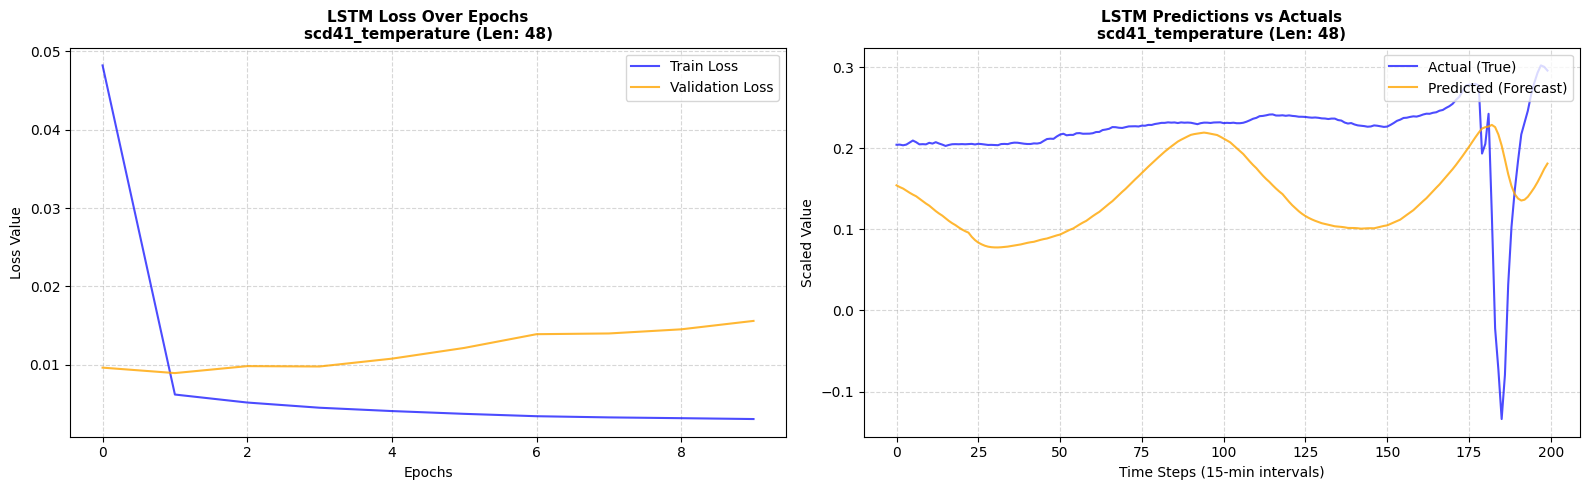

 Finished displaying graphs for scd41_temperature (len=48)

TRAINING NOW: Target = scd41_humidity | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.011900, Val Loss: 0.030228
Epoch 2, Train Loss: 0.001064, Val Loss: 0.026831
Epoch 3, Train Loss: 0.000779, Val Loss: 0.028852
Epoch 4, Train Loss: 0.000603, Val Loss: 0.027286
Epoch 5, Train Loss: 0.000494, Val Loss: 0.027095
Epoch 6, Train Loss: 0.000424, Val Loss: 0.036744
Epoch 7, Train Loss: 0.000380, Val Loss: 0.031170
Epoch 8, Train Loss: 0.000322, Val Loss: 0.033528
Epoch 9, Train Loss: 0.000283, Val Loss: 0.027760
Epoch 10, Train Loss: 0.000250, Val Loss: 0.032293

========

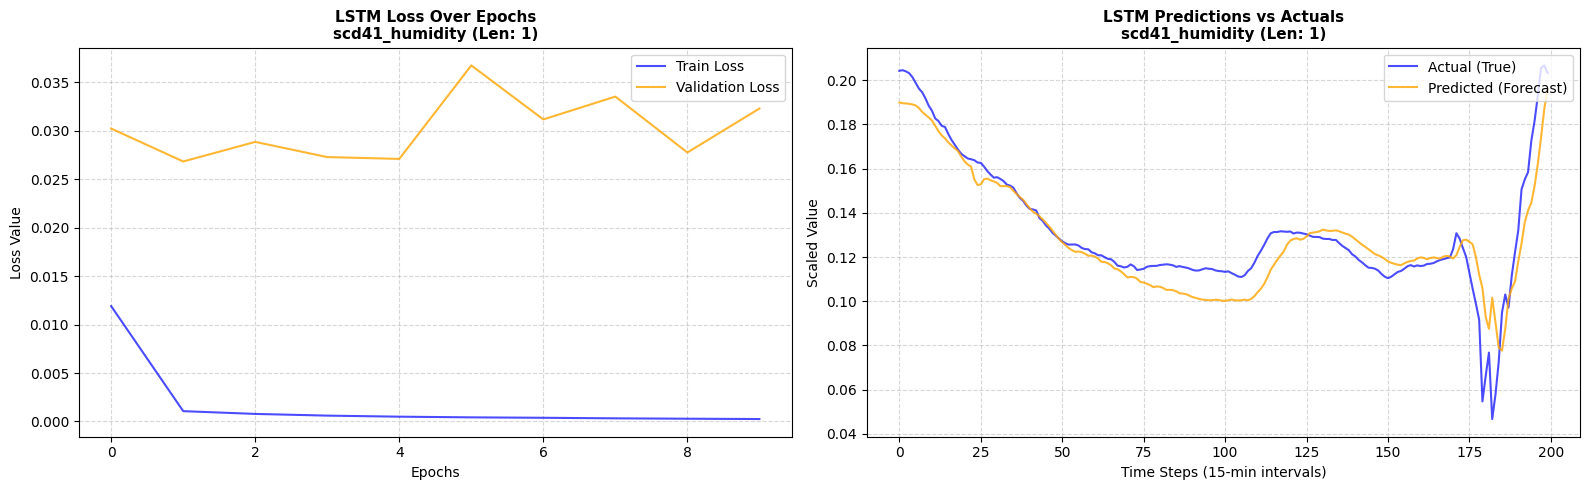

 Finished displaying graphs for scd41_humidity (len=1)

TRAINING NOW: Target = scd41_humidity | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)
Epoch 1, Train Loss: 0.019872, Val Loss: 0.011059
Epoch 2, Train Loss: 0.002016, Val Loss: 0.005657
Epoch 3, Train Loss: 0.001569, Val Loss: 0.004191
Epoch 4, Train Loss: 0.001334, Val Loss: 0.003727
Epoch 5, Train Loss: 0.001181, Val Loss: 0.003895
Epoch 6, Train Loss: 0.001073, Val Loss: 0.004180
Epoch 7, Train Loss: 0.001011, Val Loss: 0.004169
Epoch 8, Train Loss: 0.000954, Val Loss: 0.003558
Epoch 9, Train Loss: 0.000899, Val Loss: 0.003233
Epoch 10, Train Loss: 0.000861, Val Loss: 0.003001

========== M

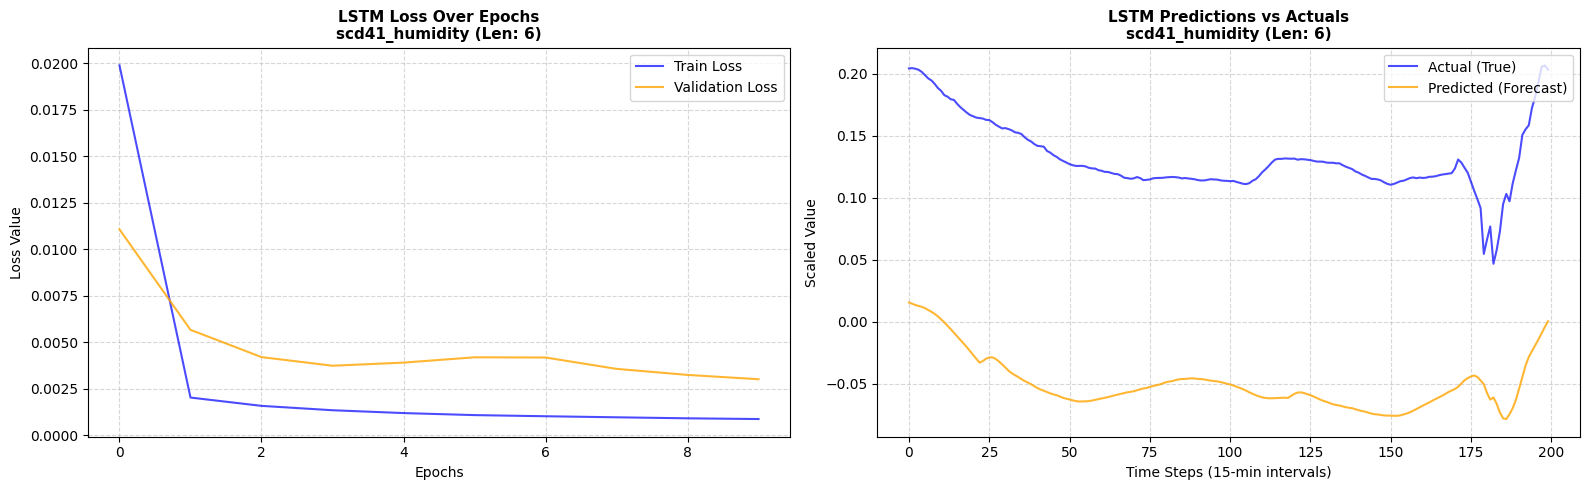

 Finished displaying graphs for scd41_humidity (len=6)

TRAINING NOW: Target = scd41_humidity | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)
Epoch 1, Train Loss: 0.025596, Val Loss: 0.017028
Epoch 2, Train Loss: 0.002331, Val Loss: 0.016674
Epoch 3, Train Loss: 0.002073, Val Loss: 0.014583
Epoch 4, Train Loss: 0.001883, Val Loss: 0.017693
Epoch 5, Train Loss: 0.001730, Val Loss: 0.014172
Epoch 6, Train Loss: 0.001575, Val Loss: 0.013237
Epoch 7, Train Loss: 0.001467, Val Loss: 0.014822
Epoch 8, Train Loss: 0.001387, Val Loss: 0.018024
Epoch 9, Train Loss: 0.001320, Val Loss: 0.015902
Epoch 10, Train Loss: 0.001287, Val Loss: 0.015893

========

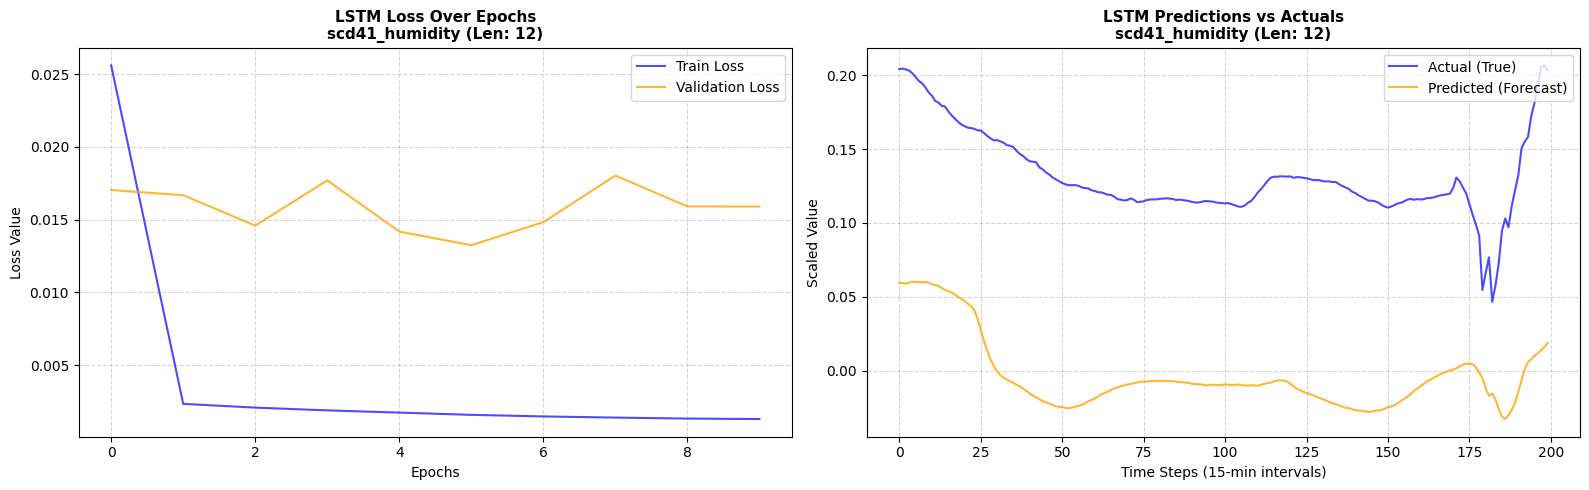

 Finished displaying graphs for scd41_humidity (len=12)

TRAINING NOW: Target = scd41_humidity | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)
Epoch 1, Train Loss: 0.026487, Val Loss: 0.007806
Epoch 2, Train Loss: 0.002992, Val Loss: 0.005906
Epoch 3, Train Loss: 0.002679, Val Loss: 0.006028
Epoch 4, Train Loss: 0.002483, Val Loss: 0.008004
Epoch 5, Train Loss: 0.002359, Val Loss: 0.006626
Epoch 6, Train Loss: 0.002224, Val Loss: 0.005802
Epoch 7, Train Loss: 0.002135, Val Loss: 0.005934
Epoch 8, Train Loss: 0.002061, Val Loss: 0.007230
Epoch 9, Train Loss: 0.001996, Val Loss: 0.006703
Epoch 10, Train Loss: 0.001937, Val Loss: 0.008717

=======

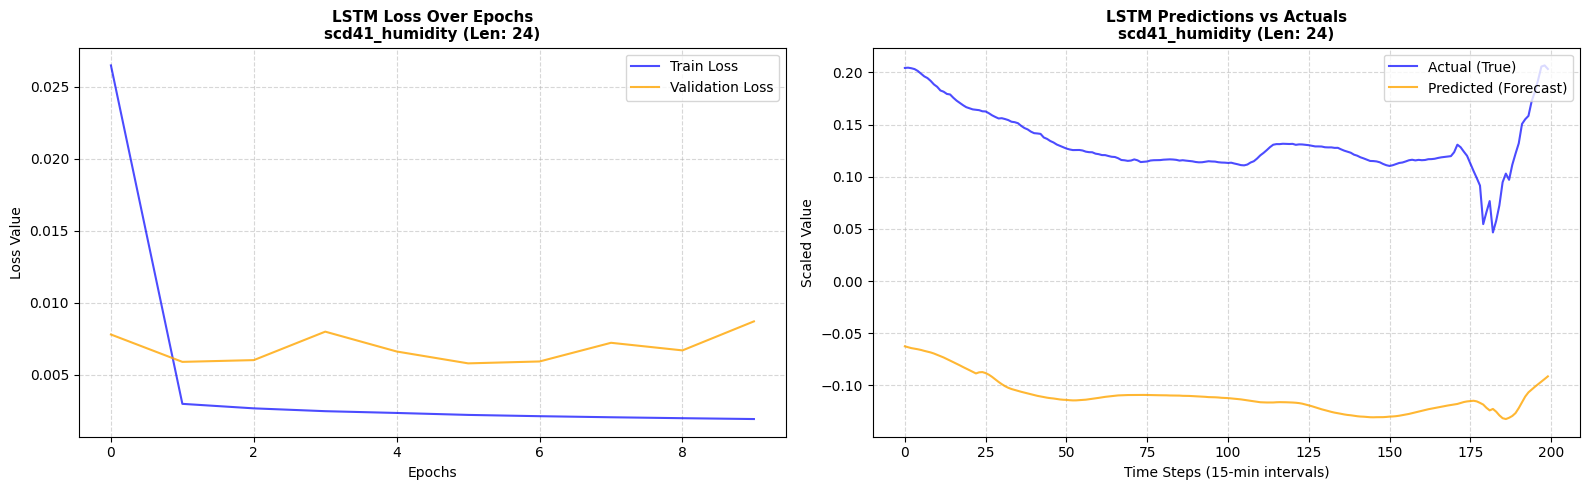

 Finished displaying graphs for scd41_humidity (len=24)

TRAINING NOW: Target = scd41_humidity | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)
Epoch 1, Train Loss: 0.025341, Val Loss: 0.101600
Epoch 2, Train Loss: 0.003964, Val Loss: 0.098838
Epoch 3, Train Loss: 0.003580, Val Loss: 0.095224
Epoch 4, Train Loss: 0.003419, Val Loss: 0.092504
Epoch 5, Train Loss: 0.003310, Val Loss: 0.096421
Epoch 6, Train Loss: 0.003204, Val Loss: 0.095612
Epoch 7, Train Loss: 0.003134, Val Loss: 0.097176
Epoch 8, Train Loss: 0.003046, Val Loss: 0.097686
Epoch 9, Train Loss: 0.002992, Val Loss: 0.089399
Epoch 10, Train Loss: 0.002917, Val Loss: 0.093478

=======

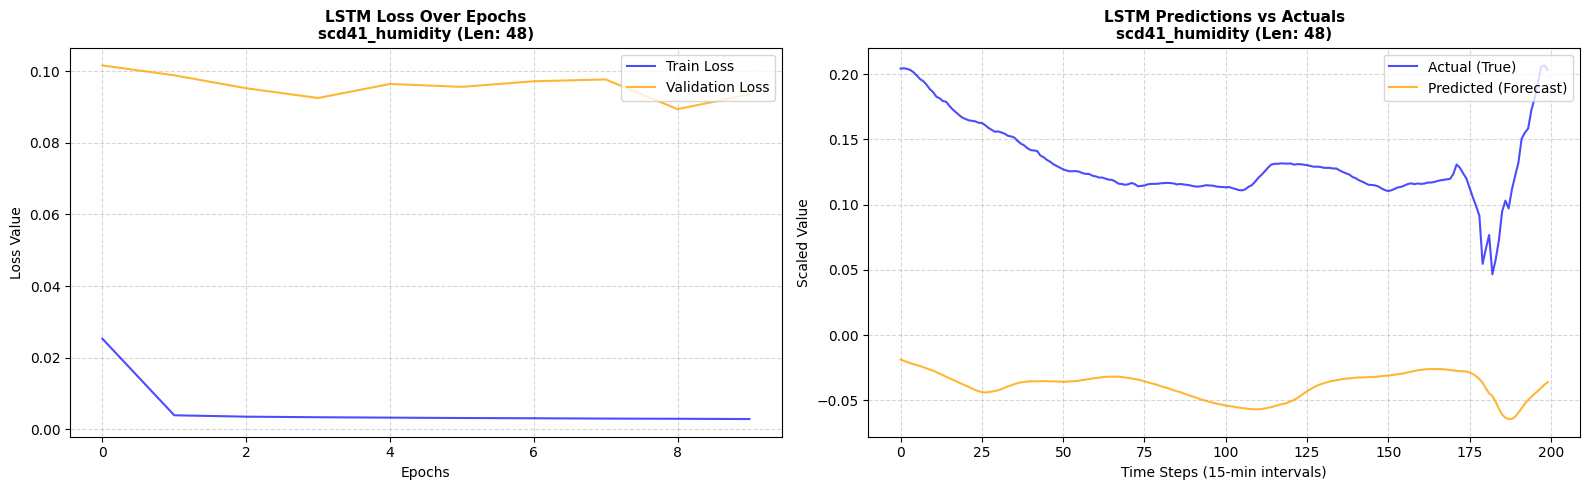

 Finished displaying graphs for scd41_humidity (len=48)

TRAINING NOW: Target = scd41_co2 | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.006365, Val Loss: 0.003648
Epoch 2, Train Loss: 0.002395, Val Loss: 0.002784
Epoch 3, Train Loss: 0.001784, Val Loss: 0.003590
Epoch 4, Train Loss: 0.001339, Val Loss: 0.003457
Epoch 5, Train Loss: 0.001007, Val Loss: 0.004271
Epoch 6, Train Loss: 0.000777, Val Loss: 0.006660
Epoch 7, Train Loss: 0.000648, Val Loss: 0.004295
Epoch 8, Train Loss: 0.000571, Val Loss: 0.004291
Epoch 9, Train Loss: 0.000523, Val Loss: 0.004292
Epoch 10, Train Loss: 0.000491, Val Loss: 0.004809

========== MODEL

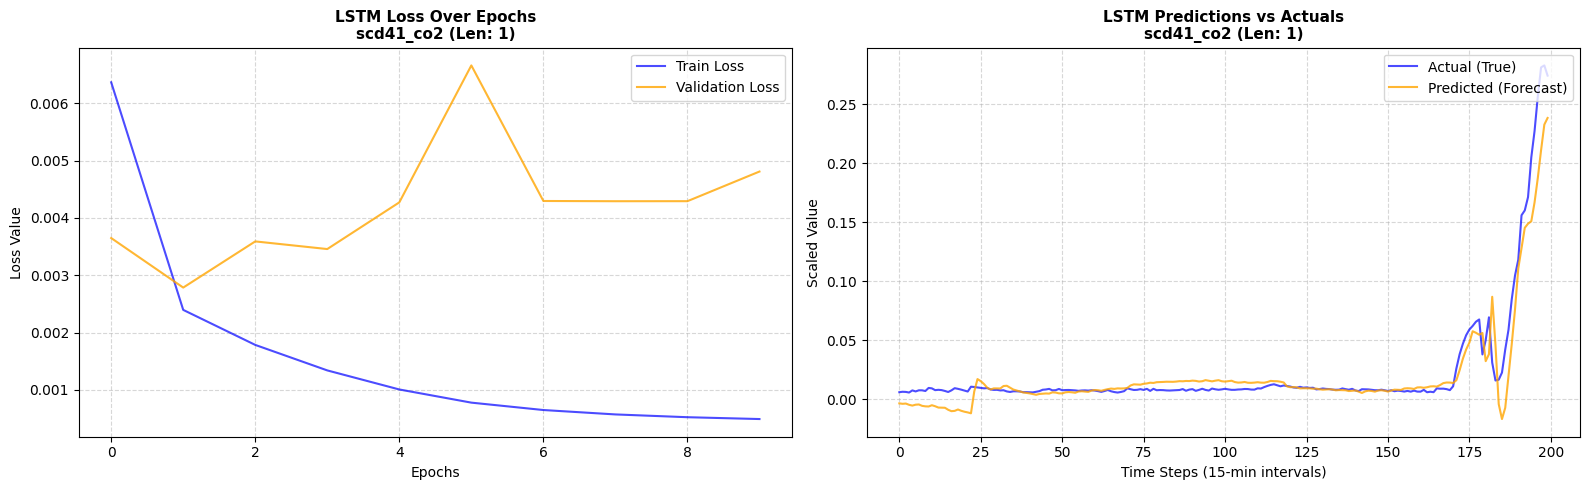

 Finished displaying graphs for scd41_co2 (len=1)

TRAINING NOW: Target = scd41_co2 | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)
Epoch 1, Train Loss: 0.005793, Val Loss: 0.005242
Epoch 2, Train Loss: 0.003318, Val Loss: 0.005013
Epoch 3, Train Loss: 0.002979, Val Loss: 0.006103
Epoch 4, Train Loss: 0.002765, Val Loss: 0.006558
Epoch 5, Train Loss: 0.002572, Val Loss: 0.006644
Epoch 6, Train Loss: 0.002407, Val Loss: 0.005915
Epoch 7, Train Loss: 0.002275, Val Loss: 0.006501
Epoch 8, Train Loss: 0.002189, Val Loss: 0.005900
Epoch 9, Train Loss: 0.002109, Val Loss: 0.006286
Epoch 10, Train Loss: 0.002147, Val Loss: 0.004784

========== MODEL EVALU

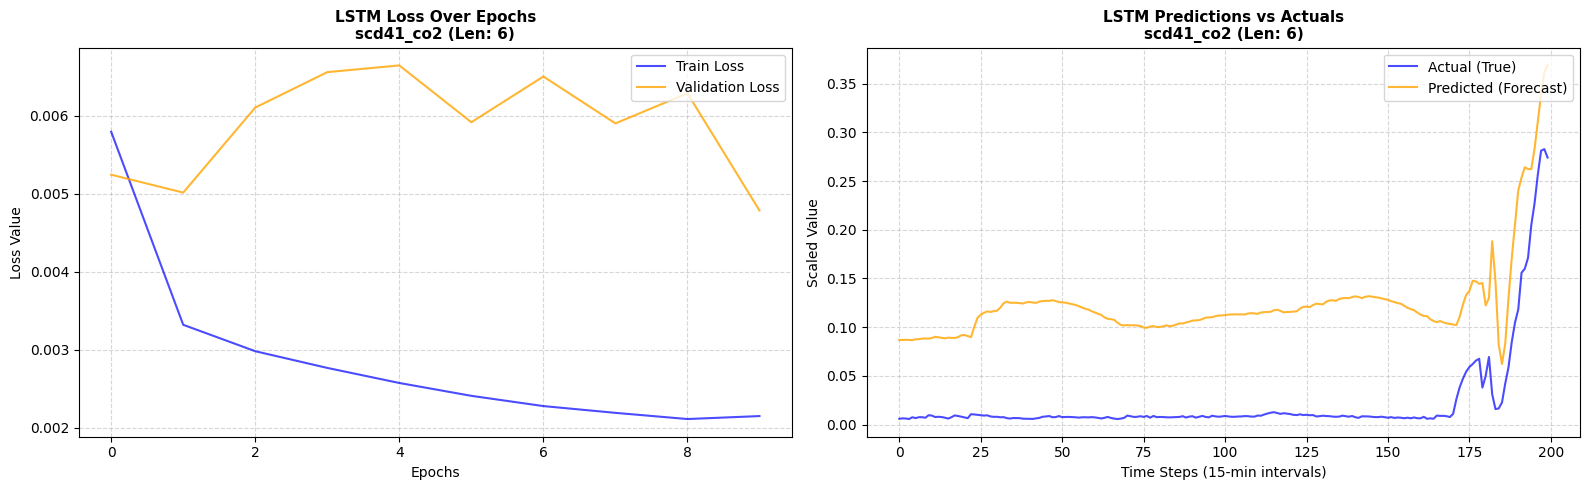

 Finished displaying graphs for scd41_co2 (len=6)

TRAINING NOW: Target = scd41_co2 | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)
Epoch 1, Train Loss: 0.006102, Val Loss: 0.006257
Epoch 2, Train Loss: 0.003870, Val Loss: 0.005140
Epoch 3, Train Loss: 0.003600, Val Loss: 0.004937
Epoch 4, Train Loss: 0.003410, Val Loss: 0.004741
Epoch 5, Train Loss: 0.003252, Val Loss: 0.004777
Epoch 6, Train Loss: 0.003155, Val Loss: 0.004618
Epoch 7, Train Loss: 0.003041, Val Loss: 0.004625
Epoch 8, Train Loss: 0.002989, Val Loss: 0.004490
Epoch 9, Train Loss: 0.002914, Val Loss: 0.004623
Epoch 10, Train Loss: 0.002860, Val Loss: 0.004454

========== MODEL E

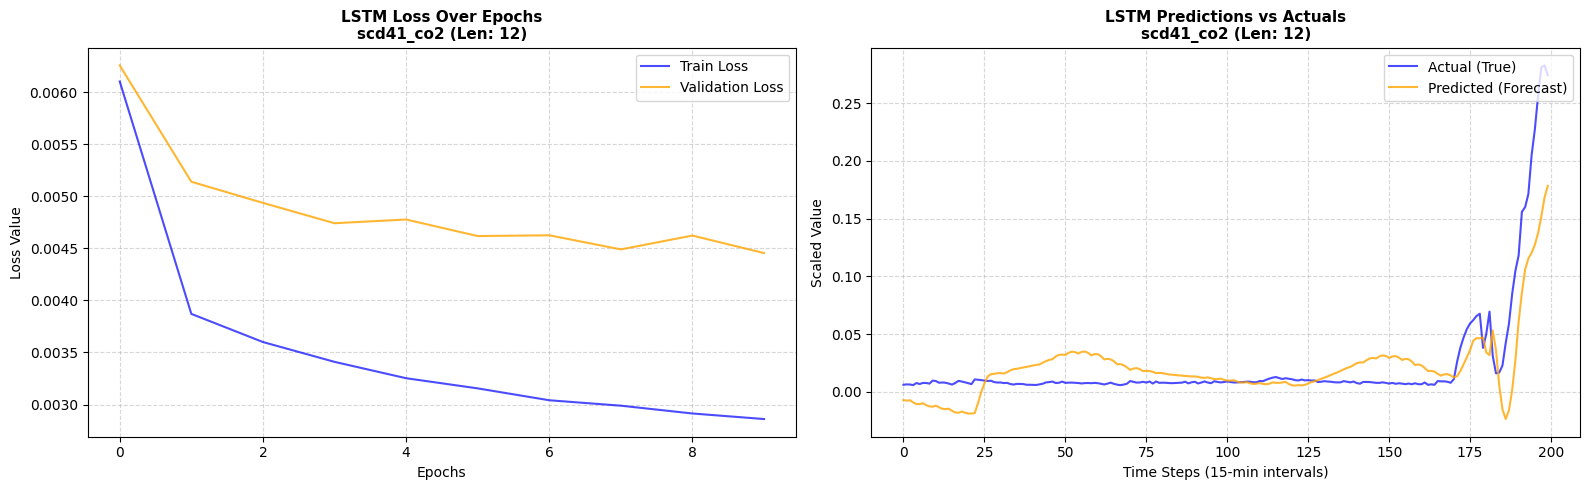

 Finished displaying graphs for scd41_co2 (len=12)

TRAINING NOW: Target = scd41_co2 | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)
Epoch 1, Train Loss: 0.006520, Val Loss: 0.006465
Epoch 2, Train Loss: 0.004537, Val Loss: 0.007044
Epoch 3, Train Loss: 0.004272, Val Loss: 0.007349
Epoch 4, Train Loss: 0.004104, Val Loss: 0.008289
Epoch 5, Train Loss: 0.003993, Val Loss: 0.007422
Epoch 6, Train Loss: 0.003882, Val Loss: 0.007740
Epoch 7, Train Loss: 0.003787, Val Loss: 0.007667
Epoch 8, Train Loss: 0.003719, Val Loss: 0.007386
Epoch 9, Train Loss: 0.003643, Val Loss: 0.007891
Epoch 10, Train Loss: 0.003585, Val Loss: 0.007703

========== MODEL 

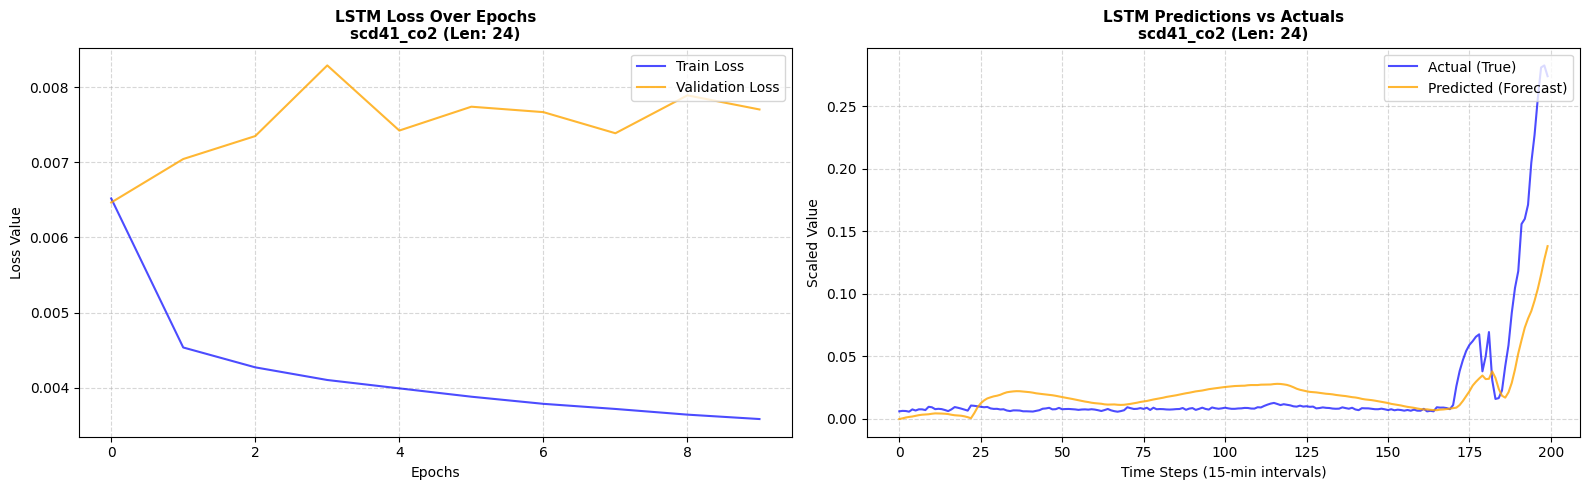

 Finished displaying graphs for scd41_co2 (len=24)

TRAINING NOW: Target = scd41_co2 | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)
Epoch 1, Train Loss: 0.007571, Val Loss: 0.007397
Epoch 2, Train Loss: 0.005437, Val Loss: 0.007824
Epoch 3, Train Loss: 0.005157, Val Loss: 0.008339
Epoch 4, Train Loss: 0.004987, Val Loss: 0.008906
Epoch 5, Train Loss: 0.004845, Val Loss: 0.008799
Epoch 6, Train Loss: 0.004746, Val Loss: 0.009715
Epoch 7, Train Loss: 0.004674, Val Loss: 0.009763
Epoch 8, Train Loss: 0.004566, Val Loss: 0.009882
Epoch 9, Train Loss: 0.004531, Val Loss: 0.009881
Epoch 10, Train Loss: 0.004454, Val Loss: 0.011418

========== MODEL 

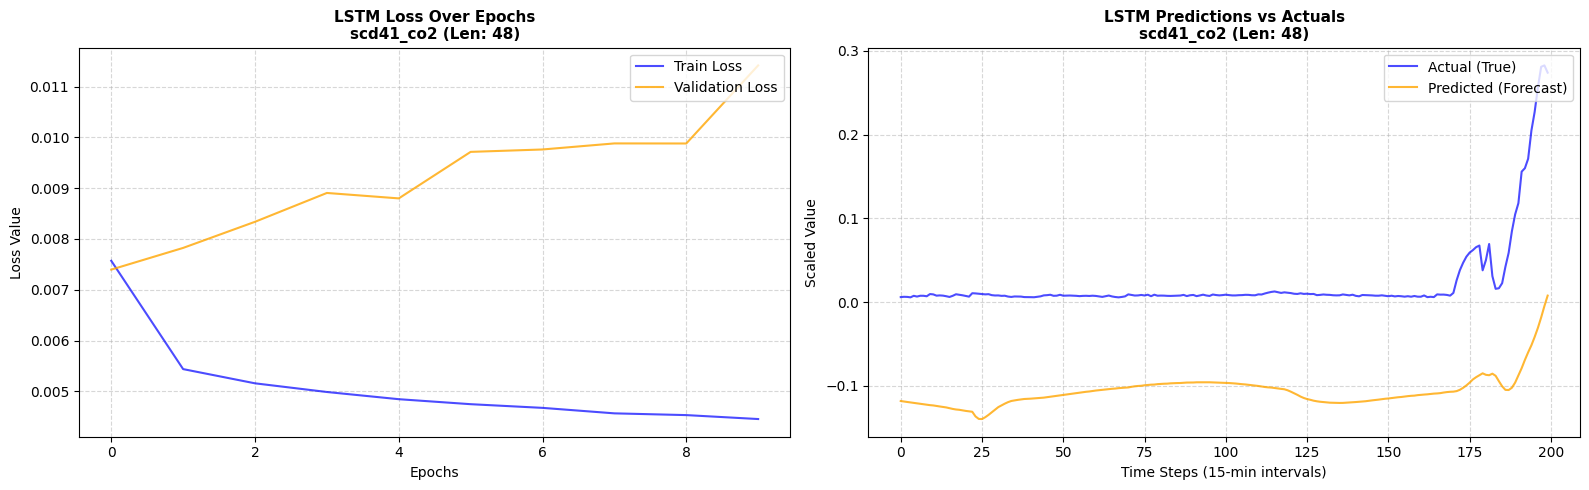

 Finished displaying graphs for scd41_co2 (len=48)

ALL EXPERIMENTS FINISHED! Everything is displayed above.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Force Jupyter to display matplotlib plots directly inside the notebook inline
%matplotlib inline

global TARGET, model_features

# ==========================================
# 1. PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  
    batch_size = 32
    
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    # Dynamically switches based on whether you are running the LSTM or CNNLSTM notebook
    if 'CNNLSTMModel' in globals():
        model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    else:
        model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
        
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER EXPERIMENT LOOP (IMMEDIATE VISUAL OUTPUT)
# ==========================================
output_lengths = [1, 6, 12, 24, 48]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

print("Starting standard LSTM automation run... Plots will appear instantly after each variant finishes!")

for target in target_features:
    for out_len in output_lengths:
        print("\n" + "="*60)
        print(f"TRAINING NOW: Target = {target} | Output Length = {out_len}")
        print("="*60)
        
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            # Extract target lines for predictions
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
            
            # ------------------------------------------------------------
            # PLOT IMMEDIATELY SIDE-BY-SIDE (1 Row, 2 Columns)
            # ------------------------------------------------------------
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            # Left Plot: Loss Curve
            axes[0].plot(results["train_losses"], label="Train Loss", color="blue", alpha=0.7)
            axes[0].plot(results["val_losses"], label="Validation Loss", color="orange", alpha=0.8)
            axes[0].set_title(f"LSTM Loss Over Epochs\n{target} (Len: {out_len})", fontsize=11, fontweight="bold")
            axes[0].set_xlabel("Epochs")
            axes[0].set_ylabel("Loss Value")
            axes[0].legend(loc="upper right")
            axes[0].grid(True, linestyle="--", alpha=0.5)
            
            # Right Plot: Predictions vs Actuals
            axes[1].plot(plot_actuals, label="Actual (True)", color="blue", alpha=0.7)
            axes[1].plot(plot_preds, label="Predicted (Forecast)", color="orange", alpha=0.8)
            axes[1].set_title(f"LSTM Predictions vs Actuals\n{target} (Len: {out_len})", fontsize=11, fontweight="bold")
            axes[1].set_xlabel("Time Steps (15-min intervals)")
            axes[1].set_ylabel("Scaled Value")
            axes[1].legend(loc="upper right")
            axes[1].grid(True, linestyle="--", alpha=0.5)
            
            plt.tight_layout()
            plt.show()  # Forces the plots to flash instantly below the logs!
            
            print(f" Finished displaying graphs for {target} (len={out_len})")
            
        except Exception as e:
            print(f"Error during variant [{target} | Length {out_len}]: {e}")

print("\nALL EXPERIMENTS FINISHED! Everything is displayed above.")

In [31]:
## 11111111

Starting automation run... Training all models first. Please wait...
Running background training for: ens160_aqi (Len: 1)

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.001780, Val Loss: 0.002270
Epoch 2, Train Loss: 0.000634, Val Loss: 0.001772
Epoch 3, Train Loss: 0.000508, Val Loss: 0.002657
Epoch 4, Train Loss: 0.000446, Val Loss: 0.002653
Epoch 5, Train Loss: 0.000402, Val Loss: 0.002858
Epoch 6, Train Loss: 0.000361, Val Loss: 0.002561
Epoch 7, Train Loss: 0.000331, Val Loss: 0.002108
Epoch 8, Train Loss: 0.000305, Val Loss: 0.002283
Epoch 9, Train Loss: 0.000282, Val Loss: 0.002358
Epoch 10, Train Loss: 0.000268, Val Loss: 0.002191

====

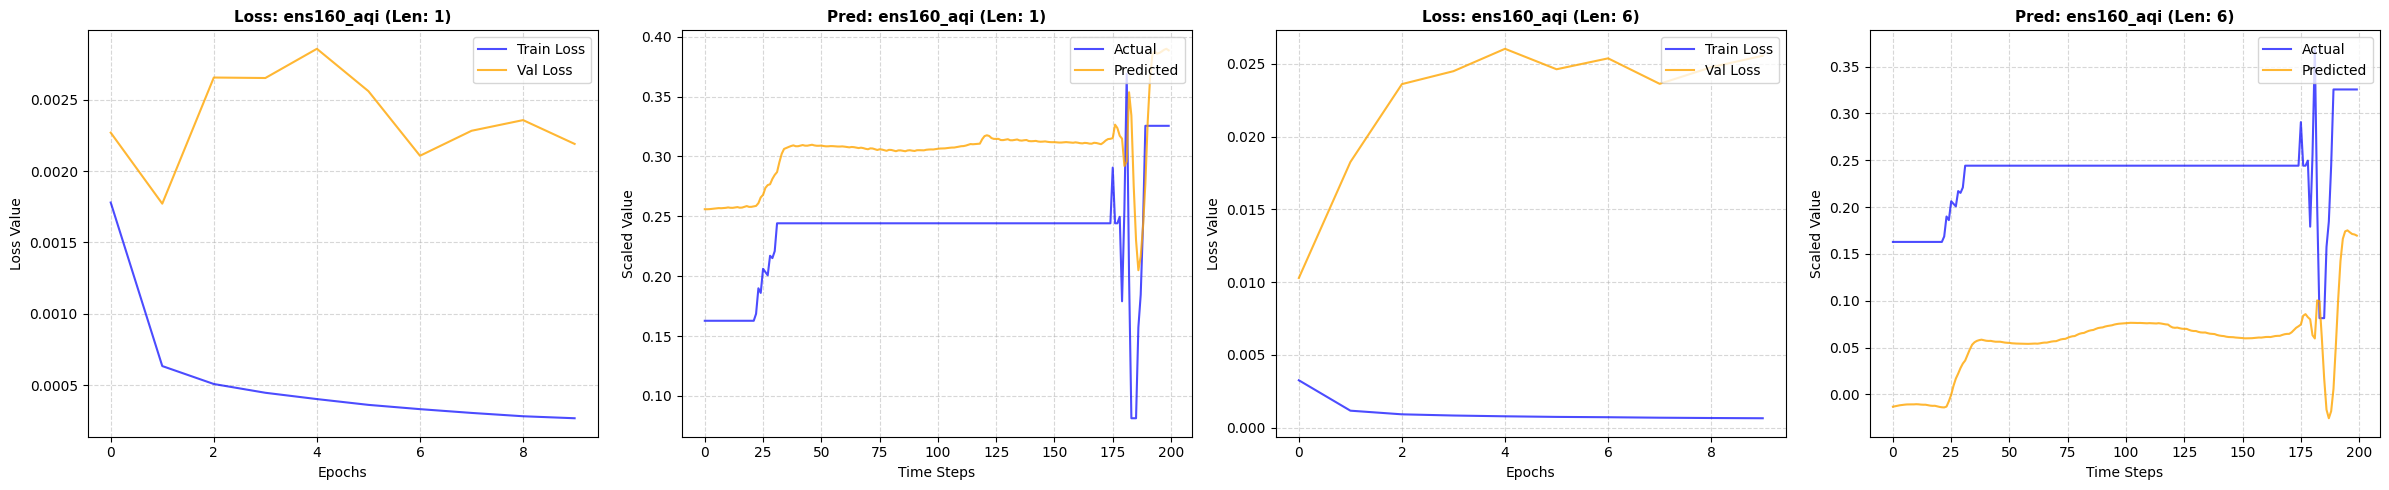

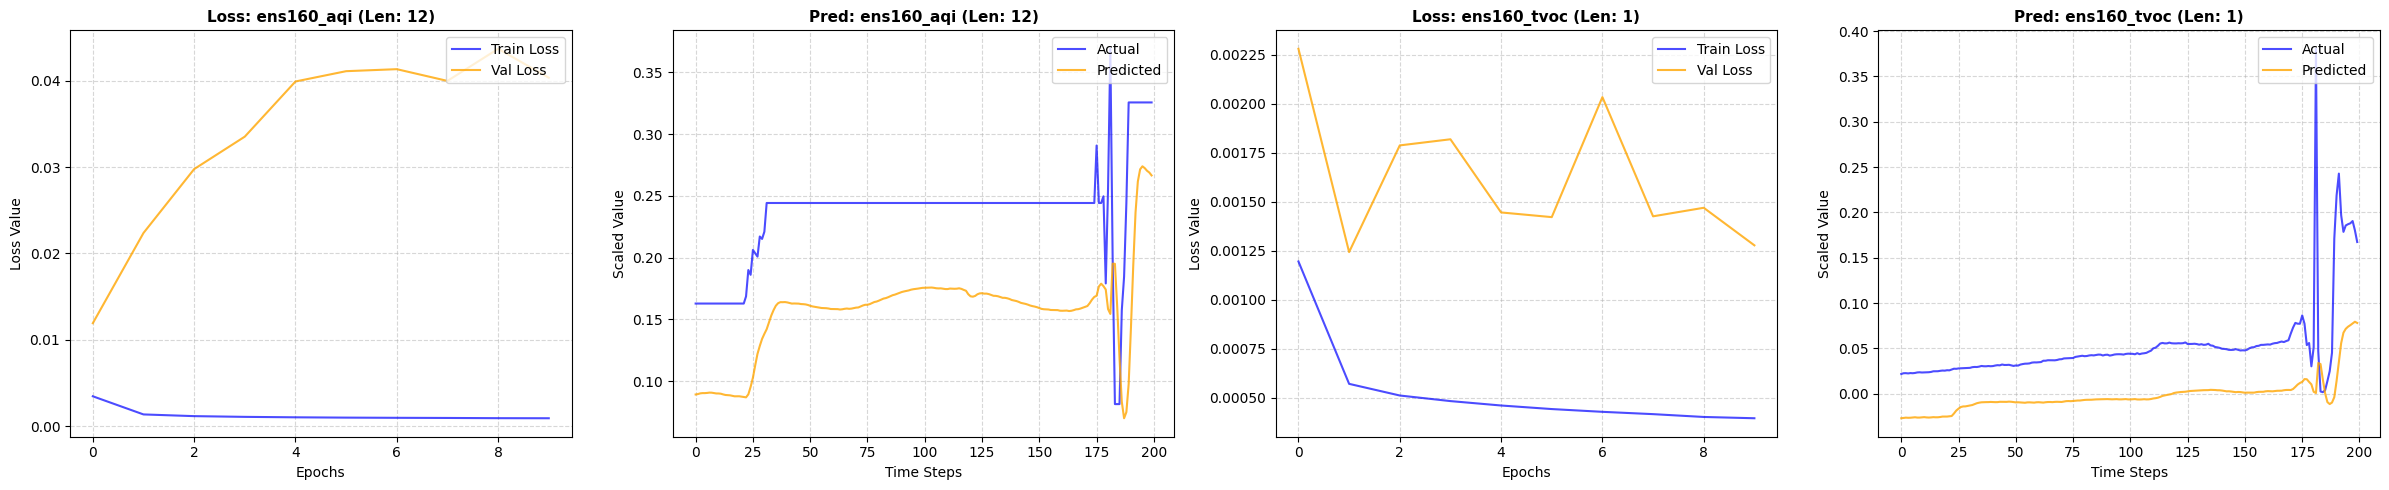

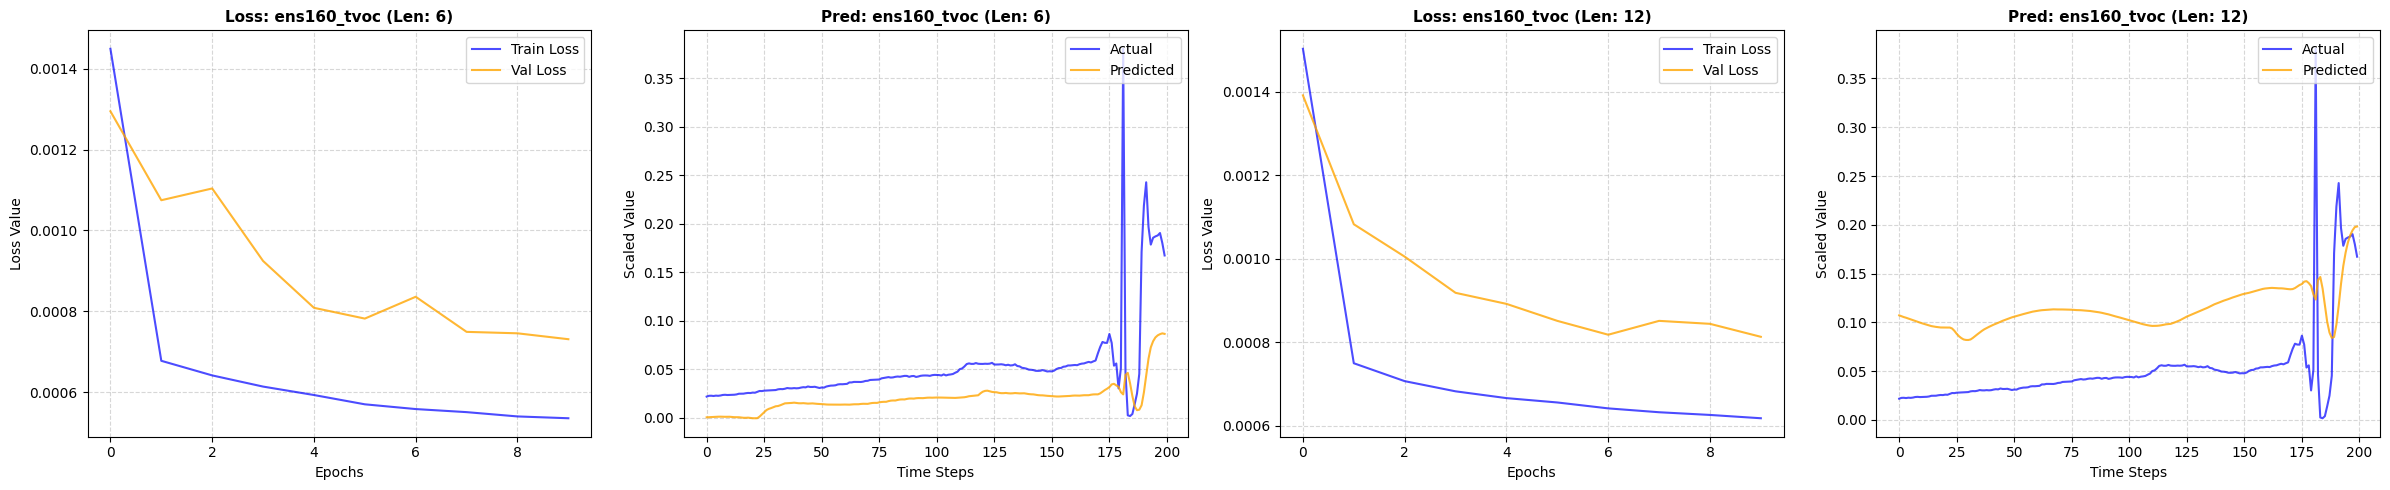

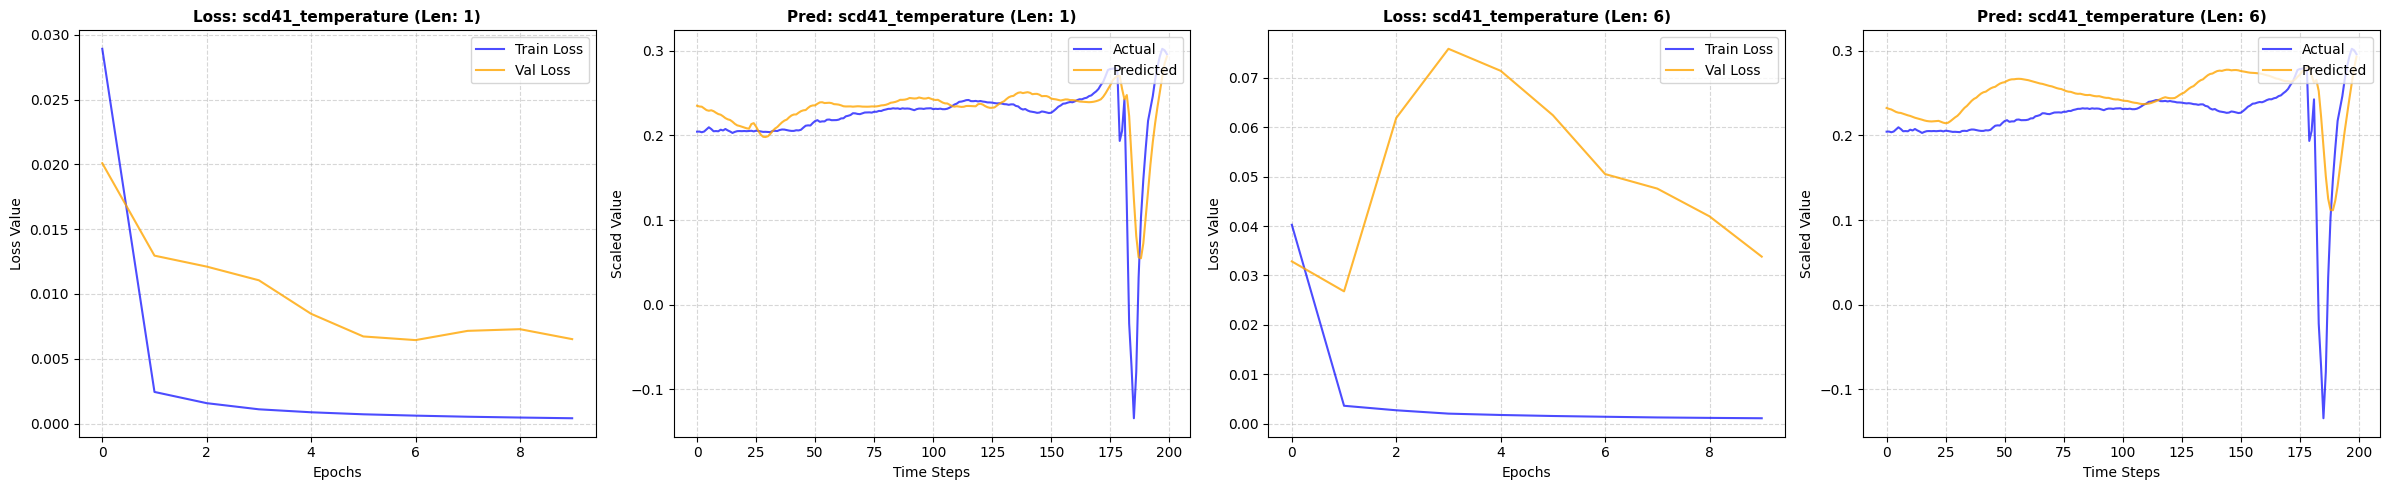

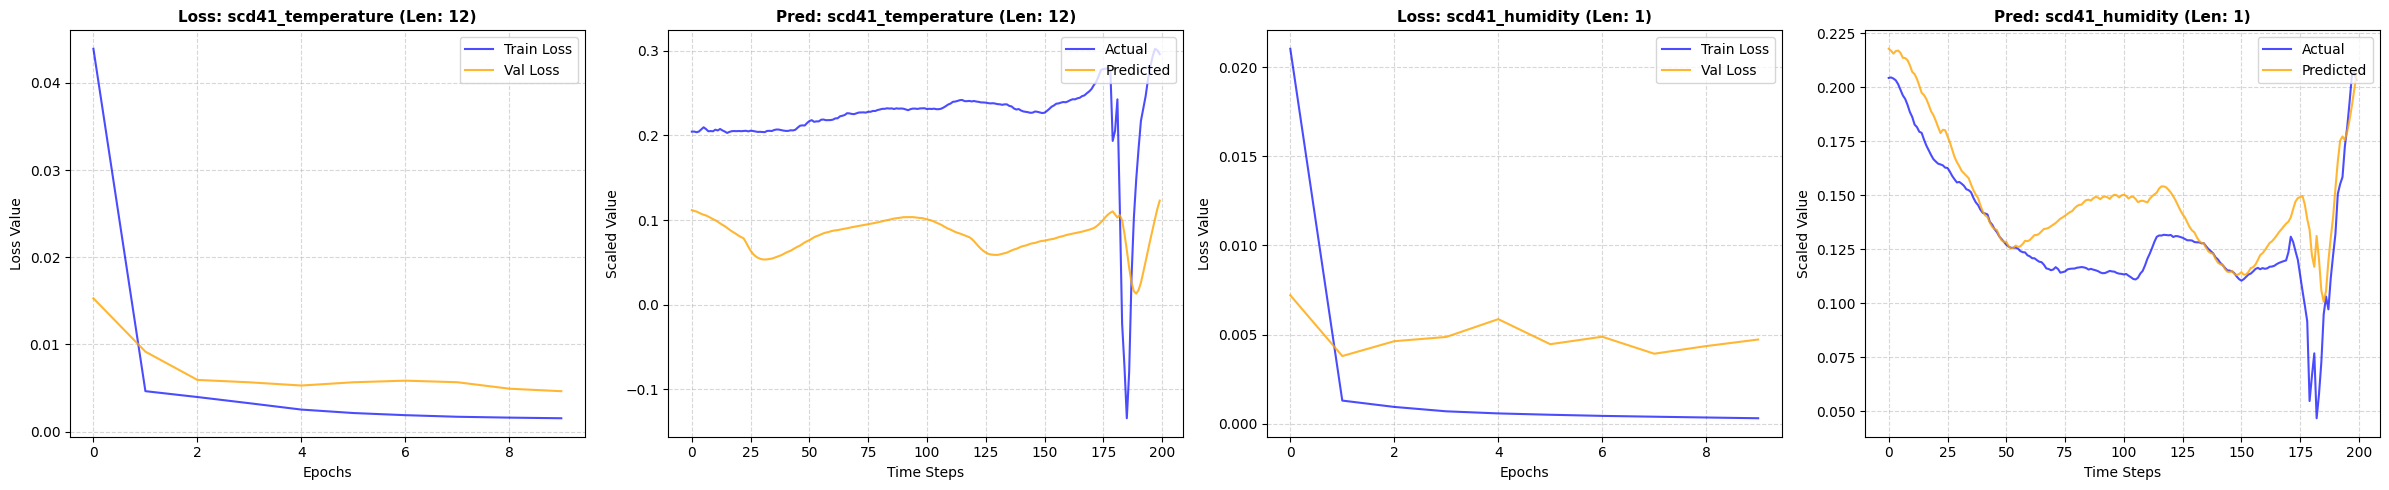

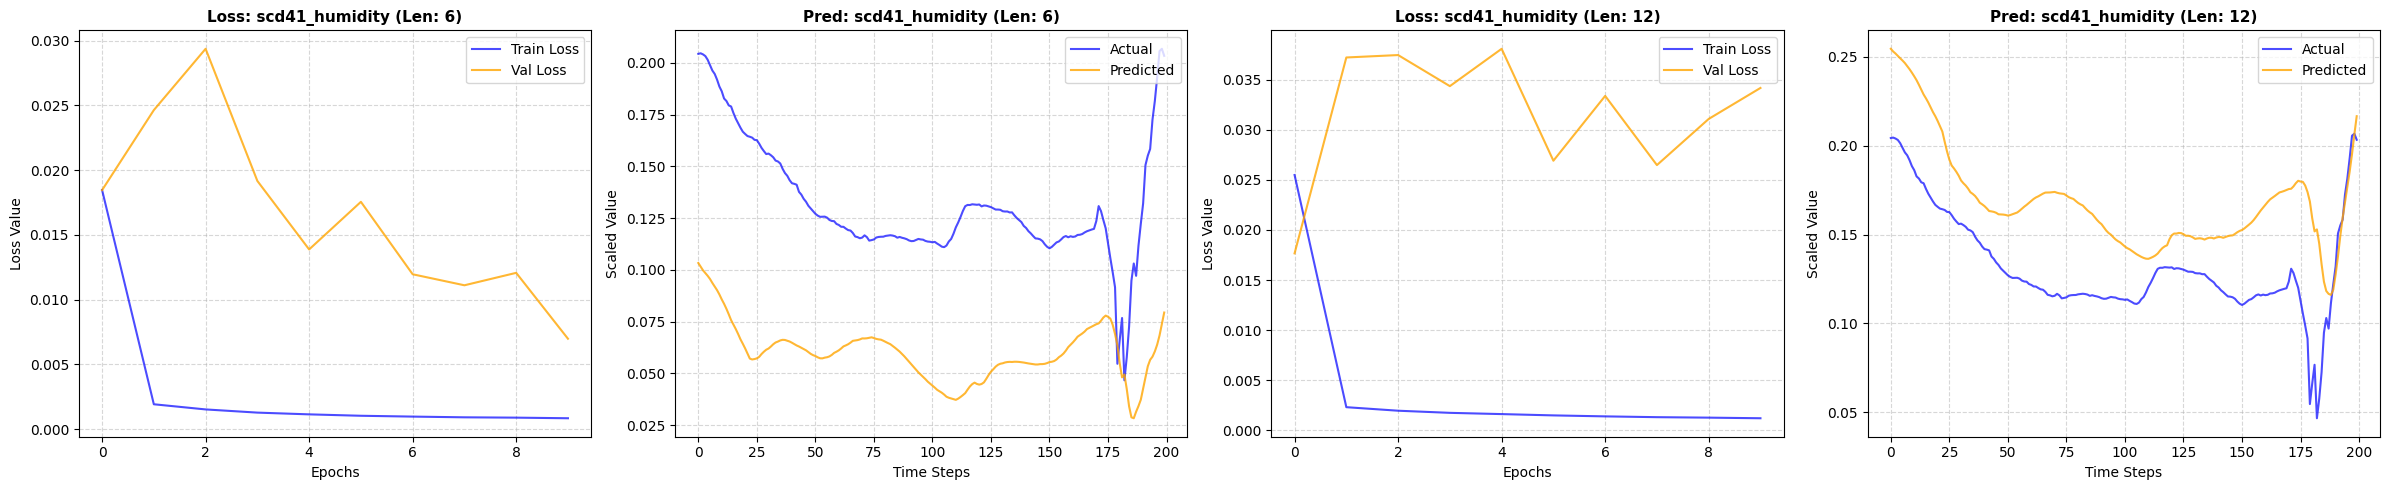

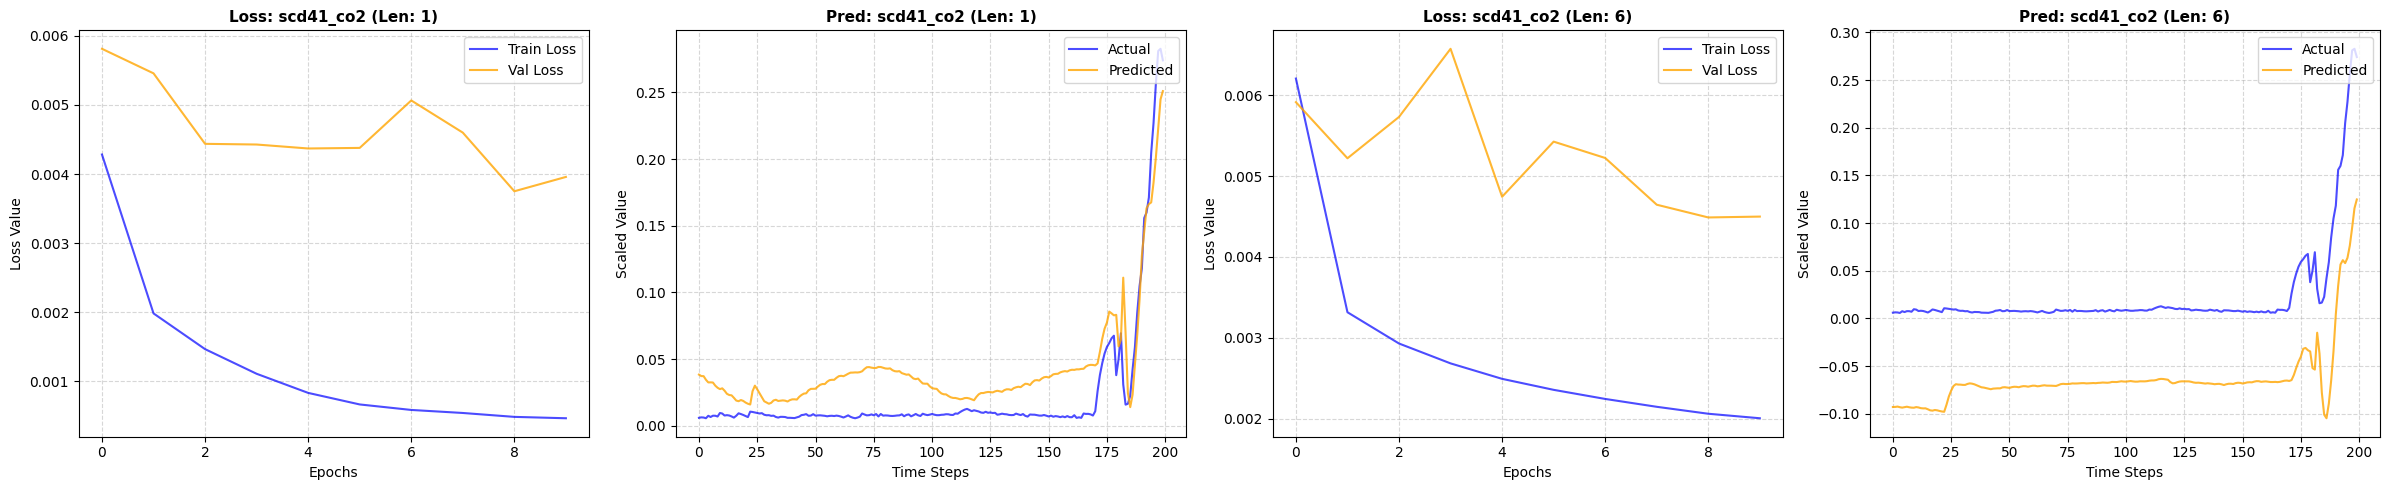

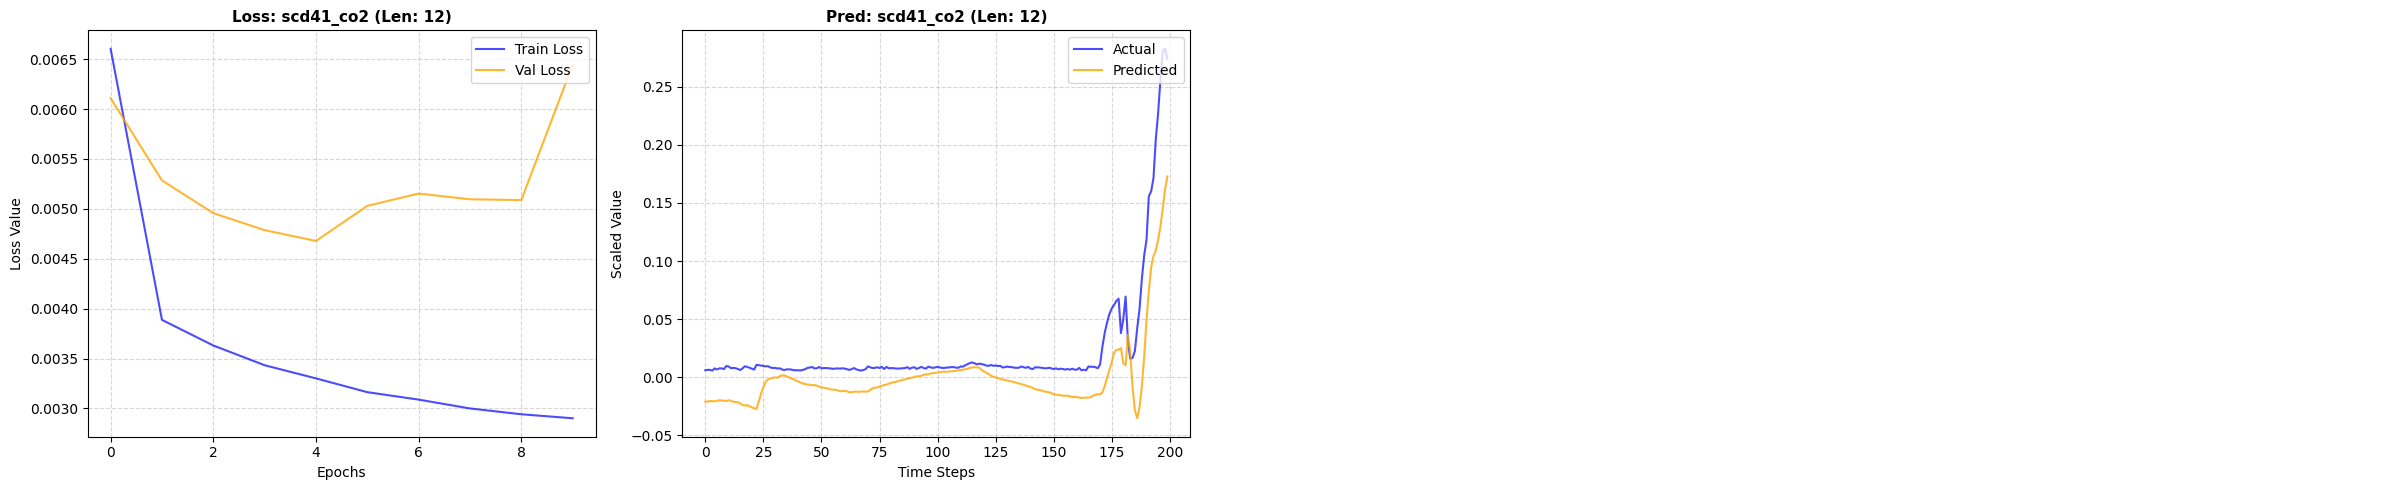


 DONE! Every single model graph has been printed above.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Force Jupyter to display matplotlib plots directly inside the notebook inline
%matplotlib inline

global TARGET, model_features

# ==========================================
# 1. PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  
    batch_size = 32
    
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    # Dynamically switches based on whether you are running the LSTM or CNNLSTM notebook
    if 'CNNLSTMModel' in globals():
        model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    else:
        model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
        
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER EXPERIMENT LOOP (SILENT TRAINING)
# ==========================================
output_lengths = [1, 6, 12]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

# This list holds all plots until the very end
all_plots_storage = []

print("Starting automation run... Training all models first. Please wait...")

for target in target_features:
    for out_len in output_lengths:
        print(f"Running background training for: {target} (Len: {out_len})")
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            # Extract target lines for predictions
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
            
            # Store Loss Plot data
            all_plots_storage.append({
                "type": "loss",
                "title": f"Loss: {target} (Len: {out_len})",
                "data1": results["train_losses"],
                "data2": results["val_losses"],
                "label1": "Train Loss",
                "label2": "Val Loss"
            })
            
            # Store Prediction Plot data
            all_plots_storage.append({
                "type": "pred",
                "title": f"Pred: {target} (Len: {out_len})",
                "data1": plot_actuals,
                "data2": plot_preds,
                "label1": "Actual",
                "label2": "Predicted"
            })
            
        except Exception as e:
            print(f"Error during training [{target} | Length {out_len}]: {e}")

# ==========================================
# 3. SHOW ALL RESULTS AT THE VERY END (4 PER ROW)
# ==========================================
print("\n" + "="*60)
print(" TRAINING COMPLETE! Showing all results below:")
print("="*60 + "\n")

plots_per_row = 4
total_plots = len(all_plots_storage)

# Loop over the stored items 4 at a time to build rows
for i in range(0, total_plots, plots_per_row):
    current_chunk = all_plots_storage[i : i + plots_per_row]
    num_cols = len(current_chunk)
    
    # Create a clean horizontal grid row
    fig, axes = plt.subplots(1, plots_per_row, figsize=(24, 5))
    
    # Fallback handle if only 1 plot is left at the end
    if plots_per_row == 1:
        axes = [axes]
        
    for col_idx in range(plots_per_row):
        ax = axes[col_idx]
        
        if col_idx < num_cols:
            item = current_chunk[col_idx]
            
            # Plot data lines
            ax.plot(item["data1"], label=item["label1"], color="blue", alpha=0.7)
            ax.plot(item["data2"], label=item["label2"], color="orange", alpha=0.8)
            ax.set_title(item["title"], fontsize=11, fontweight="bold")
            ax.legend(loc="upper right")
            ax.grid(True, linestyle="--", alpha=0.5)
            
            if item["type"] == "loss":
                ax.set_xlabel("Epochs")
                ax.set_ylabel("Loss Value")
            else:
                ax.set_xlabel("Time Steps")
                ax.set_ylabel("Scaled Value")
        else:
            # Hide blank remaining plot boxes
            ax.axis('off')
            
    plt.tight_layout()
    plt.show() # Shows this row of 4 graphs together instantly

print("\n DONE! Every single model graph has been printed above.")

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

global TARGET, model_features

# ==========================================
# 1. LSTM PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  # 6 hours lookback history
    batch_size = 32
    
    # --- Step A: Sequence Creation ---
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    # --- Step B: Data Loaders ---
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    # --- Step C: Initialize standard LSTM Model ---
    model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    
    # --- Step D: Train Model (Runs at optimal lr=0.001) ---
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    
    # --- Step E: Evaluate Model ---
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER AUTOMATION LOOP
# ==========================================
output_lengths = [1, 6, 12]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

all_results_summary = []
output_base_dir = "lstm_experiment_results"
os.makedirs(output_base_dir, exist_ok=True)

print("Starting standard LSTM automation run with clean 2-line plotting logic...")

for target in target_features:
    for out_len in output_lengths:
        print("\n" + "="*50)
        print(f"RUNNING LSTM EXPERIMENT: Target = {target} | Output Length = {out_len}")
        print("="*50)
        
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            # Record key error metrics: MSE, MAE, RMSE
            all_results_summary.append({
                "Target_Feature": target,
                "Output_Length": out_len,
                "MSE": results["mse"],
                "MAE": results["mae"],
                "RMSE": results["rmse"]
            })
            
            # ------------------------------------------
            # GRAPH 1: Clean Actual vs Predicted (Exactly Two Lines)
            # ------------------------------------------
            plt.figure(figsize=(12, 6))
            
            # Flattening out the timeline slice to avoid multi-line window overlaps
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
                
            plt.plot(plot_actuals, label="Actual", color="blue", alpha=0.7)
            plt.plot(plot_preds, label="Predicted", color="orange", alpha=0.8)
            
            plt.title(f"LSTM Predictions vs Actuals - {target} (Len: {out_len})")
            plt.xlabel("Time Steps")
            plt.ylabel("Scaled Value")
            plt.legend()
            
            plot_filename = f"{output_base_dir}/plot_{target}_len_{out_len}.png"
            plt.savefig(plot_filename)
            plt.close()
            
            # ------------------------------------------
            # GRAPH 2: Training & Validation Loss Plot
            # ------------------------------------------
            plt.figure(figsize=(12, 6))
            plt.plot(results["train_losses"], label="Train Loss", color="blue")
            plt.plot(results["val_losses"], label="Validation Loss", color="orange")
            plt.title(f"LSTM Model Loss Over Epochs - {target} (Len: {out_len})")
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend()
            
            loss_filename = f"{output_base_dir}/loss_{target}_len_{out_len}.png"
            plt.savefig(loss_filename)
            plt.close()
            
            print(f"Success! Clean 2-line graphs saved for LSTM {target} (len={out_len})")
            
        except Exception as e:
            print(f"Error during experiment [{target} | Length {out_len}]: {e}")

# ==========================================
# 3. EXPORT EXCEL/CSV SHEET
# ==========================================
if all_results_summary:
    df_summary = pd.DataFrame(all_results_summary)
    summary_path = f"{output_base_dir}/master_metrics_summary.csv"
    df_summary.to_csv(summary_path, index=False)
    print(f"\nDONE! All 15 standard LSTM variants computed successfully. View results folder: '{output_base_dir}'")
else:
    print("\nLoop execution failed. Review errors above.")

Starting standard LSTM automation run with clean 2-line plotting logic...

RUNNING LSTM EXPERIMENT: Target = ens160_aqi | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)
Epoch 1, Train Loss: 0.003563, Val Loss: 0.002098
Epoch 2, Train Loss: 0.000898, Val Loss: 0.002754
Epoch 3, Train Loss: 0.000613, Val Loss: 0.001512
Epoch 4, Train Loss: 0.000497, Val Loss: 0.001137
Epoch 5, Train Loss: 0.000442, Val Loss: 0.000911
Epoch 6, Train Loss: 0.000392, Val Loss: 0.000591
Epoch 7, Train Loss: 0.000355, Val Loss: 0.000509
Epoch 8, Train Loss: 0.000322, Val Loss: 0.000369
Epoch 9, Train Loss: 0.000293, Val Loss: 0.000339
Epoch 10, Train Loss: 0.000270, Val Lo